**Function 6- Bayesian Optimisation**

# Function 6 Description

You’re optimising a cake recipe using a black-box function with five ingredient inputs, for example flour, sugar, eggs, butter and milk. Each recipe is evaluated with a combined score based on flavour, consistency, calories, waste and cost, where each factor contributes negative points as judged by an expert taster. This means the total score is negative by design.

To frame this as a maximisation problem, your goal is to bring that score as close to zero as possible or, equivalently, to maximise the negative of the total sum.

# Starting point

* Input - 5D array (20,5)
* Output - 1D array (20,)
* Optimisation goal - Maximise

# Bayesian Optimisation (BO) workflow on capstone project
* BO with Upper Control Bound (UCB)
* Visuals of progress and surrogate intuition
* Final training with the optimized hyperparameters

### Import Libraries

In [1]:
import io, math, pathlib, numpy as np, pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import KFold, cross_val_score
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel as C
from scipy.stats import norm

import warnings
warnings.filterwarnings("ignore")

#### Setup Parameters

In [2]:
plt.rcParams['figure.figsize'] = (5,3)
plt.rcParams['figure.dpi'] = 140
plt.rcParams['axes.grid'] = True

### Assign Data to variables X and y

In [3]:
import numpy as np, pandas as pd, pathlib

# To load a .npy file into a pandas DataFrame:
# 1. Load the .npy file using numpy.load()
# 2. Convert the resulting numpy array to a pandas DataFrame using pd.DataFrame()

# Attempting to load from '/content/data/' as is common in Colab, or from a 'data/' subfolder
try:
    # Try loading from /content/data/
    X_array = np.load('/content/data/initial_inputs6.npy')
    y_array = np.load('/content/data/initial_outputs6.npy')
    print("Files loaded successfully from /content/data/")

except FileNotFoundError:
    try:
        # If not in /content/data/, try loading from a 'data/' subfolder in the current directory
        X_array = np.load('data/initial_inputs6.npy')
        y_array = np.load('data/initial_outputs6.npy')
        print("Files loaded successfully from data/ subfolder.")
    except FileNotFoundError:
       print("Error: One or both .npy files not found at /content/data/ or data/.")
       print("Please ensure they are in the correct path.")
       print("Current working directory files: ", list(pathlib.Path().absolute().glob('*.npy')))
       print("Files in /content/data/: ", list(pathlib.Path('/content/data/').absolute().glob('*.npy')))

       # Create dummy data if files are not found to allow notebook execution to proceed
       X_array = np.random.rand(20, 5) # Example: 20 samples, 5 features
       y_array = np.random.rand(20,)  # Example: 20 samples, 1 output
       print("\nUsing dummy data for X and y to continue.")

# Convert to DataFrame if needed, or use as NumPy arrays directly for your model
X_df = pd.DataFrame(X_array)
y_df = pd.DataFrame(y_array, columns=['target_output'])

print("Shape of X (NumPy array):", X_array.shape)
print("Shape of y (NumPy array):", y_array.shape)
print("\nFirst 5 rows of X (DataFrame):")
display(X_df.head())
print("\nFirst 5 rows of y (DataFrame):")
display(y_df.head())

# Assign X and y for subsequent steps (as NumPy arrays, based on original notebook context)
X = X_array
y = y_array


Files loaded successfully from /content/data/
Shape of X (NumPy array): (20, 5)
Shape of y (NumPy array): (20,)

First 5 rows of X (DataFrame):


,0,1,2,3,4
0,0.728186,0.154693,0.732552,0.693997,0.056401
1,0.242384,0.844100,0.577809,0.679021,0.501953
2,0.729523,0.748106,0.679775,0.356552,0.671054
3,0.770620,0.114404,0.046780,0.648324,0.273549
4,0.618812,0.331802,0.187288,0.756238,0.328835



First 5 rows of y (DataFrame):


,target_output
0,-0.714265
1,-1.209955
2,-1.672200
3,-1.536058
4,-0.829237


To add new data points, you'll need to create new NumPy arrays for the input features (`new_X_points`) and target outputs (`new_y_points`). Ensure that the new points have the same number of features as your existing `X` array.

Then, use `np.vstack` to vertically stack the new `X` points onto the existing `X` array, and `np.concatenate` to combine the new `y` points with the existing `y` array.

In [4]:
import numpy as np

# Assume X and y are already defined from previous cells
# Example: X_array.shape = (10, 2), y_array.shape = (10,)

# Create new data points
# Make sure new_X_points has the same number of columns as X
# and new_y_points has compatible dimensions with y

# For X (features), assume 5 features per data point
# Let's add 5 new data points
new_X_points = np.array([
    [0.999999, 0.999999, 0.999999, 0.999999, 0.999999], # week 1 capstone submission - eye ball
    [0.179793, 0.195175, 0.018860, 0.795439, 0.794344], # week 2 capstone submission - KAPPA 40.0 for exploration
    [0.909336, 0.704799, 0.695611, 0.016621, 0.081256], # week 3 capstone submission - KAPPA 60.0 for exploration
    [0.274425, 0.507814, 0.462264, 0.576454, 0.998962], # week 4 capstone submission - KAPPA 100.0 for exploration
    [0.704983, 0.140344, 0.256594, 0.023776, 0.270680], # week 5 capstone submission - KAPPA 200.0 for exploration
    [0.092327, 0.763540, 0.608342, 0.093505, 0.459382], # week 6 capstone submission - KAPPA 500.0 for exploration
    [0.560908, 0.980463, 0.550921, 0.996470, 0.944616], # week 7 capstone submission - KAPPA 10.0 for exploitation
    [0.749124, 0.627439, 0.186136, 0.289737, 0.985448], # week 8 capstone submission - KAPPA 1000.0 for exploration and changed hyperparameters
    [0.038331, 0.028954, 0.815322, 0.957619, 0.027055], # week 9 capstone submission - KAPPA 5.0 for exploitation from BO
    [0.449928, 0.294776, 0.714544, 0.995487, 0.046753], # week 10 capstone submission - KAPPA 1.0 for exploitation from BO, and returned N_INIT and N_ITER to 8.0 for a simpler BO GP model
    [0.489699, 0.268530, 0.631746, 0.934789, 0.146131], # week 11 capstone submission - KAPPA 0.5 for exploitation from BO and changed hyperparameters
    [0.412449, 0.360177, 0.447299, 0.861567, 0.041196]  # week 12 capstone submission - KAPPA 0.5
    [0.487148, 0.261959, 0.468922, 0.864640, 0.013664] # week 13 capstone submission - KAPPA 0.25
])

# For y (target), assume a single output value per data point
new_y_points = np.array([
    -2.7001258292585804,  # week 1 capstone processed output
    -1.7375698273180291,  # week 2 capstone processed output
    -1.6952768490627916,  # week 3 capstone processed output
    -1.5781077759958118,  # week 4 capstone processed output
    -1.7789963737297474,  # week 5 capstone processed output
    -1.8671204333128042,  # week 6 capstone processed output
    -1.9274694299963087,  # week 7 capstone processed output
    -2.4090513308341817,  # week 8 capstone processed output
    -1.146647311799873,   # week 9 capstone processed output
    -0.40396631056135657, # week 10 capstone processed output
    -0.4329409561543445,  # week 11 capstone processed output
    -0.3576296027065349   # week 12 capstone processed output
     # week 13 capstone processed output
])

# Verify shapes before adding
print(f"Original X shape: {X.shape}")
print(f"Original y shape: {y.shape}")
print(f"New X points shape: {new_X_points.shape}")
print(f"New y points shape: {new_y_points.shape}")

# Add the new data points
X = np.vstack([X, new_X_points])
y = np.concatenate([y, new_y_points])

print(f"\nUpdated X shape: {X.shape}")
print(f"Updated y shape: {y.shape}")

# Display the last few rows to see the added data
print("\nLast 5 rows of updated X:")
display(pd.DataFrame(X).tail())
print("\nLast 5 rows of updated y:")
display(pd.DataFrame(y, columns=['target_output']).tail())


Original X shape: (20, 5)
Original y shape: (20,)
New X points shape: (12, 5)
New y points shape: (12,)

Updated X shape: (32, 5)
Updated y shape: (32,)

Last 5 rows of updated X:


,0,1,2,3,4
27,0.749124,0.627439,0.186136,0.289737,0.985448
28,0.038331,0.028954,0.815322,0.957619,0.027055
29,0.449928,0.294776,0.714544,0.995487,0.046753
30,0.489699,0.268530,0.631746,0.934789,0.146131
31,0.412449,0.360177,0.447299,0.861567,0.041196



Last 5 rows of updated y:


,target_output
27,-2.409051
28,-1.146647
29,-0.403966
30,-0.432941
31,-0.357630


Finding the top 3 input (X) values that generated the highest output (y) values:

Top 3 Highest Output Values (y) and their corresponding X values:
   Original Index: 31
   y value: -3.5762960271e-01
   Corresponding X values: [0.412449 0.360177 0.447299 0.861567 0.041196]


   Original Index: 29
   y value: -4.0396631056e-01
   Corresponding X values: [0.449928 0.294776 0.714544 0.995487 0.046753]


   Original Index: 30
   y value: -4.3294095615e-01
   Corresponding X values: [0.489699 0.26853  0.631746 0.934789 0.146131]


Finding the top 3 input (X) values that generated the lowest output (y) values:

Top 3 Lowest Output Values (y) and their corresponding X values:
   Original Index: 20
   y value: -2.7001258293e+00
   Corresponding X values: [0.999999 0.999999 0.999999 0.999999 0.999999]


   Original Index: 8
   y value: -2.5711696316e+00
   Corresponding X values: [0.12572016 0.86272469 0.02854433 0.24660527 0.75120624]


   Original Index: 27
   y value: -2.4090513308e+00
   Co

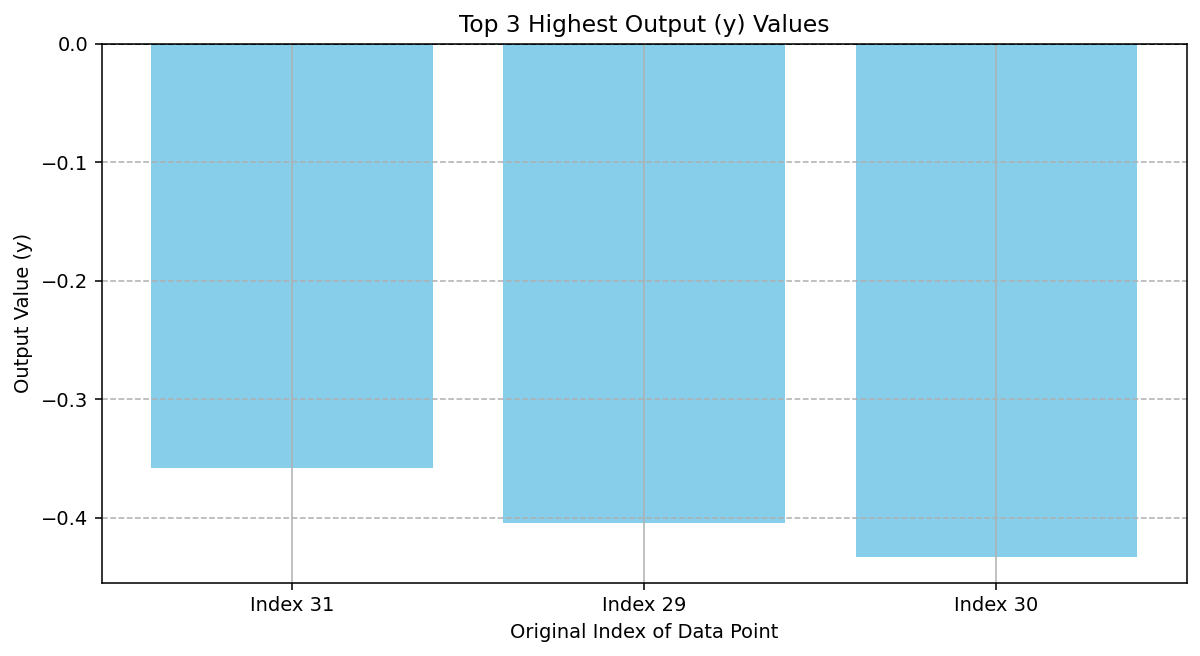

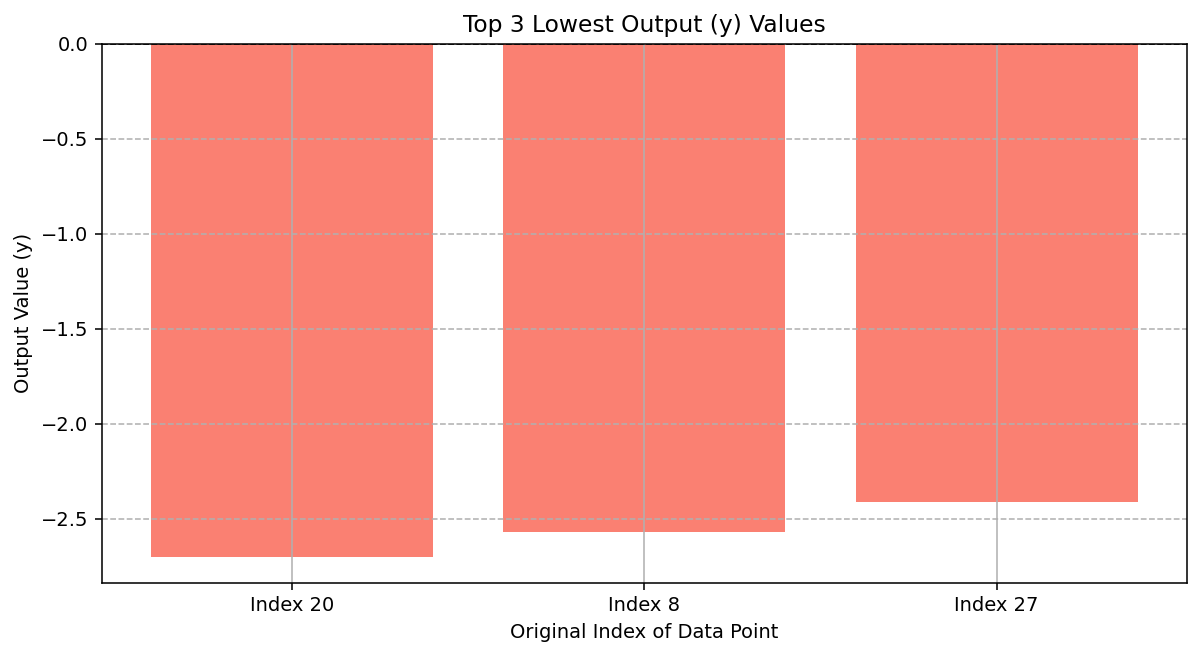

In [5]:
print("Finding the top 3 input (X) values that generated the highest output (y) values:")

# Get indices that would sort y in descending order (highest values are at the beginning)
sorted_indices_highest = np.argsort(y)[::-1]

# Select the top 3 indices for the highest y values
top_3_indices_highest = sorted_indices_highest[:3]

# Get the corresponding X and y values
top_3_X_highest = X[top_3_indices_highest]
top_3_y_highest = y[top_3_indices_highest]

print("\nTop 3 Highest Output Values (y) and their corresponding X values:")
for i, val_y in enumerate(top_3_y_highest):
  print(f"   Original Index: {top_3_indices_highest[i]}")
  print(f"   y value: {val_y:.10e}")
  print(f"   Corresponding X values: {top_3_X_highest[i]}")
  print("\n")

print("Finding the top 3 input (X) values that generated the lowest output (y) values:")

# Get indices that would sort y in ascending order (lowest values are at the beginning)
sorted_indices_lowest = np.argsort(y)

# Select the top 3 indices for the lowest y values
top_3_indices_lowest = sorted_indices_lowest[:3]

# Get the corresponding X and y values
top_3_X_lowest = X[top_3_indices_lowest]
top_3_y_lowest = y[top_3_indices_lowest]

print("\nTop 3 Lowest Output Values (y) and their corresponding X values:")
for i, val_y in enumerate(top_3_y_lowest):
  print(f"   Original Index: {top_3_indices_lowest[i]}")
  print(f"   y value: {val_y:.10e}")
  print(f"   Corresponding X values: {top_3_X_lowest[i]}")
  print("\n")

  # Plotting the top 3 highest y values
plt.figure(figsize=(10, 5))
plt.bar([f'Index {idx}' for idx in top_3_indices_highest], top_3_y_highest, color='skyblue')
plt.axhline(0, color='black', linestyle='--', linewidth=0.8) # Added baseline at y=0
plt.xlabel('Original Index of Data Point')
plt.ylabel('Output Value (y)')
plt.title('Top 3 Highest Output (y) Values')
plt.grid(axis='y', linestyle='--')
plt.show()

# Plotting the top 3 lowest y values
plt.figure(figsize=(10, 5))
plt.bar([f'Index {idx}' for idx in top_3_indices_lowest], top_3_y_lowest, color='salmon')
plt.axhline(0, color='black', linestyle='--', linewidth=0.8) # Added baseline at y=0
plt.xlabel('Original Index of Data Point')
plt.ylabel('Output Value (y)')
plt.title('Top 3 Lowest Output (y) Values')
plt.grid(axis='y', linestyle='--')
plt.show()

### Objective and baseline
Baseline model provides us the RMSE benchmark as a starting point

In [6]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.ensemble import GradientBoostingRegressor

cv = KFold(n_splits=5, shuffle=True, random_state=42)
def rmse_cv(model):
    scores = cross_val_score(model, X, y, cv=cv, scoring="neg_mean_squared_error")
    return float(np.sqrt(-scores).mean())

baseline = GradientBoostingRegressor(random_state=42)
baseline_rmse = rmse_cv(baseline)
print(f"Baseline GBR RMSE (5-fold): {baseline_rmse:.3f}")

Baseline GBR RMSE (5-fold): 0.413


### Search Space and Helper Functions

In [7]:
# Search space for 5D input (n_estimators, learning_rate, max_depth, subsample, min_samples_leaf)
space = {
    "n_estimators": (50, 400),        # Integer
    "learning_rate": (0.01, 0.50),    # Float Week 8 increased upper bound to 0.50 from 0.30 after reviewing learning rate plots and best rmse
    "max_depth": (1, 15),             # Integer (added) changed to 15 from 10, week 11
    "subsample": (0.2, 1.0),          # Float (added) redcued to 0.2 from 0.5, week 11
    "min_samples_leaf": (1, 20)       # Integer (added)
}
hp = list(space.keys()); d = len(hp) # d will now be 5

# Converts normalized values in [0,1] into actual hyperparameter values (and rounds when needed, e.g., integers)
def to_params(x01):
    out = {}
    for i, name in enumerate(hp):
        lo, hi = space[name]
        v = lo + x01[i]*(hi-lo)
        if name in ["n_estimators", "max_depth", "min_samples_leaf"]:
            v = int(round(v))
        out[name] = float(v) # Store all as float initially, cast to int where needed in objective
    return out

# Builds a GradientBoostingRegressor with given params and returns its 5-fold CV RMSE. So BO minimizes error (RMSE)
def objective(params):
    model = GradientBoostingRegressor(
        n_estimators=int(params["n_estimators"]),
        learning_rate=float(params["learning_rate"]),
        max_depth=int(params["max_depth"]),
        subsample=float(params["subsample"]),
        min_samples_leaf=int(params["min_samples_leaf"]),
        random_state=42
    )
    return rmse_cv(model)

# The normal_pdf and normal_cdf functions remain unchanged
def normal_pdf(z):
    # Using scipy.stats.norm for robustness, assuming it's available from initial imports
    return norm.pdf(z)

def normal_cdf(z):
    # Using scipy.stats.norm for robustness, assuming it's available from initial imports
    return norm.cdf(z)

### Step by Step BO with UCB decomposition

#### Import Libraries

In [8]:
from dataclasses import dataclass
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel as C
import numpy as np, pandas as pd, matplotlib.pyplot as plt

#### Dataclass to store all details of each step in the optimization

In [9]:
@dataclass
class StepLog:
    it: int; params: dict; rmse: float; mu: float; sigma: float; ei: float
    exploit_contrib: float; explore_contrib: float; tag: str; best_rmse: float

**Control the knobs for the BO run**
* N_INIT = number of warm-up random trials before BO starts learning
* N_ITER = number of BO-guided iterations
* KAPPA = exploration bias parameter for Upper Confidence Bound (UCB)
* N_CAND = how many candidate points to evaluate at each step
* rng = random generator for reproducibility

In [10]:
N_INIT, N_ITER, KAPPA, N_CAND = 8, 8.0, 0.25, 2000
#N_INIT, N_ITER, KAPPA, N_CAND = 8, 8.0, 0.50, 2000
# N_INIT, N_ITER, KAPPA, N_CAND = 8, 8.0, 0.50, 2000
# N_INIT, N_ITER, KAPPA, N_CAND = 8, 8.0, 1.0, 2000 # change KAPPA to 1.0 back to default N_INIT and N_ITER, simplied model
# N_INIT, N_ITER, KAPPA, N_CAND = 15, 50.0, 5.0, 2000 # change KAPPA to 5
# N_INIT, N_ITER, KAPPA, N_CAND = 15, 50.0, 1000.0, 2000 # update hyperparameters as surrogate After BO plot is not showing any improvement
# N_INIT, N_ITER, KAPPA, N_CAND = 8, 8.0, 10.0, 2000 # changed KAPPA to 10.0 for exploitation
rng = np.random.RandomState(123)

# Week 8 after adding Week 7 points to data set:

The Surrogate 'After BO' plot isn't showing the expected improvement. While the numerical output for best_rmse did decrease, the visualization suggests that the Bayesian Optimization process, with its current settings, hasn't fully refined the surrogate model or explored the landscape effectively.

This can happen if the number of iterations is too low, or if the exploration-exploitation balance (controlled by KAPPA) isn't optimal for the search space. The current settings of N_INIT=8 and N_ITER=8 are quite small for a 5-dimensional optimization problem, and a KAPPA of 10.0 still leans heavily towards exploration, even if the intent was exploitation.

To address this, I recommend the following strategy to allow the Bayesian Optimization more opportunity to learn and converge:

**Increase N_INIT (Number of Initial Warm-up Trials):** A larger, more diverse set of initial random samples will give the Gaussian Process a better foundation to build its initial understanding of the objective function. This can help prevent it from getting stuck in suboptimal regions early on.

**Increase N_ITER (Number of BO-guided Iterations):** With more iterations, the Bayesian Optimization algorithm has more chances to intelligently explore the search space, refine the surrogate model, and progressively find better hyperparameters. Eight iterations are often insufficient for complex spaces.

**Adjust KAPPA (Exploration Bias Parameter):** While you set KAPPA=10.0 with the intention of exploitation, this value is still relatively high and favors exploration. To genuinely encourage more exploitation and focus the search on promising regions that the surrogate model has identified, we can lower KAPPA further (e.g., to 2.0 or 5.0). This will make the Upper Confidence Bound acquisition function prioritize points with a better predicted mean (lower RMSE) more heavily.

**For Week 8:**
Adjusted BO Parameters: Modify the N_INIT, N_ITER, and KAPPA values. Se N_INIT to 15, N_ITER to 50, and KAPPA to 1000. This should provide more initial data, more BO search steps, and a more balanced exploration-exploitation trade-off leaning towards exploration. A KAPPA of 5.0 and 2.0 were tried initially but the surrogate slice - after BO plot for learning rate showed little improvement so instead I have tried for more aggressive exploration. Also in Week 8 I increased the upper bound of learning rate from 0.30 to 0.50 after reviewing learning rate vs best rmse plot

**For Week 9:**
data points from BO, KAPPA 5.0


**For Week 10:**
data points from BO, KAPPA 1.0

#### Warm-up trials - BO needs some initial data to train the surrogate

In [11]:
X_trials = rng.rand(N_INIT, d)
y_trials = np.array([objective(to_params(x)) for x in X_trials])
best_rmse = float(np.min(y_trials))

#### Initialize logging with warm-up trials
Will be tagged as Warm-up

In [12]:
logs = []
cum_best = np.minimum.accumulate(y_trials)
for i in range(N_INIT):
    logs.append(StepLog(i-(N_INIT-1), to_params(X_trials[i]), float(y_trials[i]), float('nan'), float('nan'),
                        float('nan'), float('nan'), float('nan'), "Warm-up", float(cum_best[i])))

#### Define surrogate (Gaussian Process)
This is the GP surrogate model that predicts mean (mu) and uncertainty (sigma)

In [13]:
kernel = C(1.0, (1e-3, 1e3)) * Matern(length_scale=np.ones(d), nu=2.5) + WhiteKernel(noise_level=1e-6, noise_level_bounds=(1e-9, 1e-2))
gpr = GaussianProcessRegressor(kernel=kernel, normalize_y=True, random_state=42, n_restarts_optimizer=3)

trace = [best_rmse]

#### Bayesian Optimization loop
For Each iteration:
1. Fit surrogate
2. Predict many candidates
3. Compute UCB
4. Pick best candidate
5. Classify step as Exploration/Exploitation
6. Evaluate real objective
7. Update logs and best_rmse

In [14]:
import time

start_time = time.time()


for it in range(1, int(N_ITER)+1):
    # Fit surrogate on all past trials
    gpr.fit(X_trials, y_trials)

    # Generate candidate points and predict mean/uncertainty
    CAND = rng.rand(N_CAND, d)
    mu, std = gpr.predict(CAND, return_std=True)

    # Compute Upper Confidence Bound (UCB) for each candidate
    # UCB = mu + KAPPA * std. We want to maximize this.
    ucb = mu + KAPPA * std

    # Pick the candidate with maximum UCB
    idx = int(np.argmax(ucb)); x_next = CAND[idx]
    mu_star, sig_star = float(mu[idx]), float(std[idx])
    # EI-related values are not directly applicable to UCB, setting to NaN or 0
    ei_star = float('nan')
    imp_star = float('nan')
    z_star = float('nan')

    # UCB is inherently a balance of exploitation (mu) and exploration (std*KAPPA)
    # We can approximate contribution for logging, or simply tag as 'UCB'
    contrib_exploit = float(mu[idx]) # Exploitation is driven by the mean prediction
    contrib_explore = float(KAPPA * std[idx]) # Exploration is driven by uncertainty weighted by KAPPA
    tag = "UCB (Exploration)" if KAPPA * std[idx] > abs(mu[idx]) else "UCB (Exploitation)"

    # Evaluate true objective at chosen point
    params_next = to_params(x_next); y_next = objective(params_next)
    X_trials = np.vstack([X_trials, x_next[None,:]])
    y_trials = np.concatenate([y_trials, [y_next]])
    if y_next < best_rmse: best_rmse = float(y_next)
    trace.append(best_rmse)

    # Log the step
    logs.append(StepLog(it, params_next, float(y_next), mu_star, sig_star, ei_star,
                        contrib_exploit, contrib_explore, tag, best_rmse))
end_time = time.time()
elapsed_time = end_time - start_time
print(f"Bayesian Optimization loop executed in {elapsed_time:.2f} seconds")


Bayesian Optimization loop executed in 12.94 seconds


#### Log final step log DataFrame

In [15]:
log_df = pd.DataFrame([{
    "iter": s.it, "tag": s.tag, "rmse": s.rmse, "best_rmse_so_far": s.best_rmse,
    "mu": s.mu, "sigma": s.sigma, "ei": s.ei,
    "exploit_contrib": s.exploit_contrib, "explore_contrib": s.explore_contrib,
    **{k: s.params[k] for k in s.params}
} for s in logs])
log_df.head(20)

,iter,tag,rmse,best_rmse_so_far,mu,sigma,ei,exploit_contrib,explore_contrib,n_estimators,learning_rate,max_depth,subsample,min_samples_leaf
0,-7,Warm-up,0.533814,0.533814,NaN,NaN,NaN,NaN,NaN,294.0,0.150208,4.0,0.641052,15.0
1,-6,Warm-up,0.560639,0.533814,NaN,NaN,NaN,NaN,NaN,198.0,0.490574,11.0,0.584746,8.0
2,-5,Warm-up,0.568608,0.533814,NaN,NaN,NaN,NaN,NaN,170.0,0.367234,7.0,0.247742,9.0
3,-4,Warm-up,0.540122,0.533814,NaN,NaN,NaN,NaN,NaN,308.0,0.099421,3.0,0.625241,11.0
4,-3,Warm-up,0.565268,0.533814,NaN,NaN,NaN,NaN,NaN,272.0,0.426222,11.0,0.688819,15.0
5,-2,Warm-up,0.566544,0.533814,NaN,NaN,NaN,NaN,NaN,163.0,0.187276,4.0,0.434971,13.0
6,-1,Warm-up,0.554918,0.533814,NaN,NaN,NaN,NaN,NaN,82.0,0.222514,7.0,0.594948,9.0
7,0,Warm-up,0.507846,0.507846,NaN,NaN,NaN,NaN,NaN,159.0,0.218912,14.0,0.955328,11.0
8,1,UCB (Exploitation),0.449113,0.449113,0.569623,0.012801,NaN,0.569623,0.003200,64.0,0.173049,14.0,0.694128,8.0
9,2,UCB (Exploitation),0.288636,0.288636,0.576236,0.026623,NaN,0.576236,0.006656,112.0,0.316676,2.0,0.245071,2.0


### Visuals

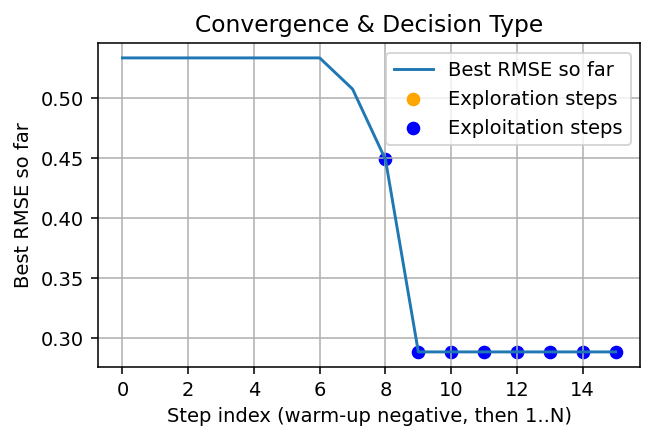

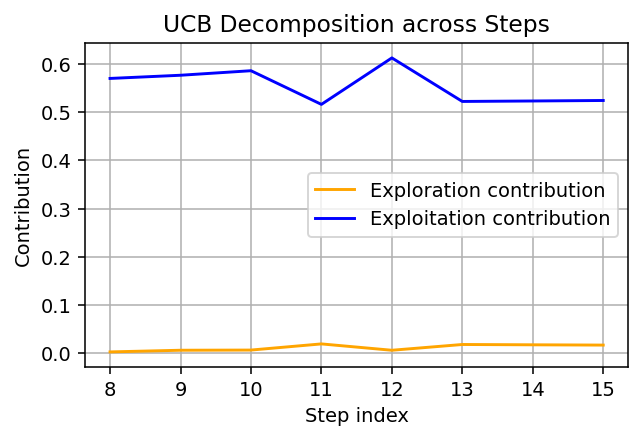

In [16]:
mask_explr = log_df["tag"] == "UCB (Exploration)"; mask_explt = log_df["tag"] == "UCB (Exploitation)"

plt.figure()
plt.plot(log_df["best_rmse_so_far"], label="Best RMSE so far")
plt.scatter(log_df.index[mask_explr], log_df.loc[mask_explr, "best_rmse_so_far"], label="Exploration steps", color="orange")
plt.scatter(log_df.index[mask_explt], log_df.loc[mask_explt, "best_rmse_so_far"], label="Exploitation steps", color="blue")
plt.xlabel("Step index (warm-up negative, then 1..N)"); plt.ylabel("Best RMSE so far")
plt.title("Convergence & Decision Type"); plt.legend(); plt.show()

plt.figure()
plt.plot(log_df["explore_contrib"], label="Exploration contribution",color="orange")
plt.plot(log_df["exploit_contrib"], label="Exploitation contribution", color="blue")
plt.xlabel("Step index"); plt.ylabel("Contribution")
plt.title("UCB Decomposition across Steps"); plt.legend(); plt.show()

#### Surrogate slice: initial vs final (for all hyperparameters)
Fits a Gaussian Process surrogate on the current trials (X_used, y_used)

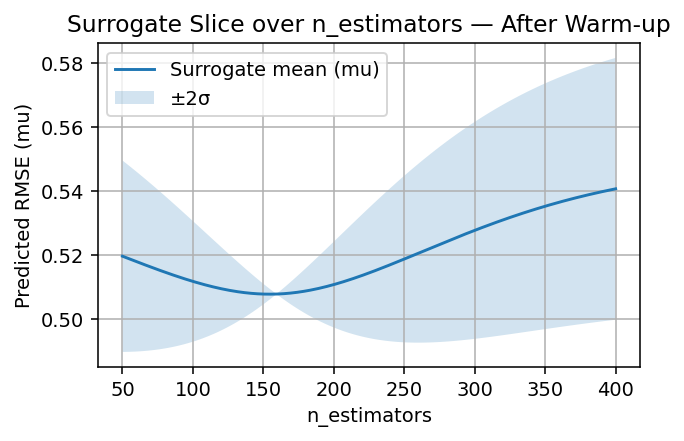

--- After Warm-up over n_estimators ---
Range of lower 2-sigma bound: [0.4898, 0.5076]
Range of upper 2-sigma bound: [0.5081, 0.5815]



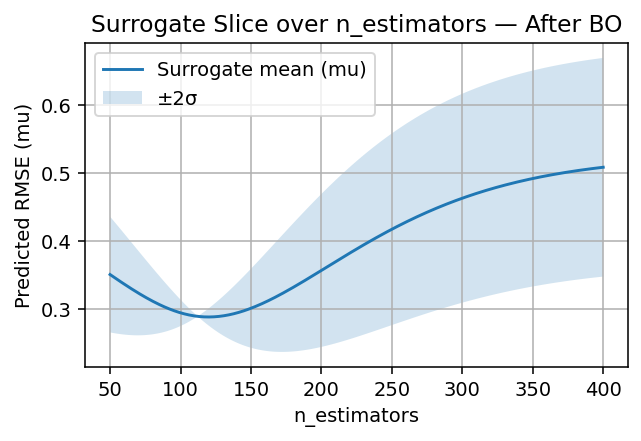

--- After BO over n_estimators ---
Range of lower 2-sigma bound: [0.2363, 0.3472]
Range of upper 2-sigma bound: [0.2893, 0.6692]



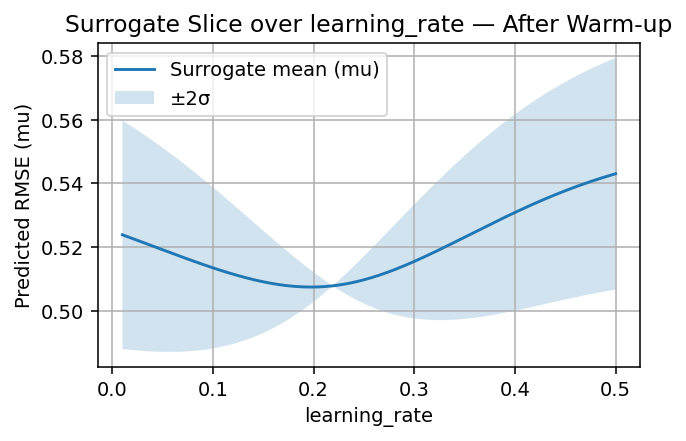

--- After Warm-up over learning_rate ---
Range of lower 2-sigma bound: [0.4871, 0.5076]
Range of upper 2-sigma bound: [0.5081, 0.5794]



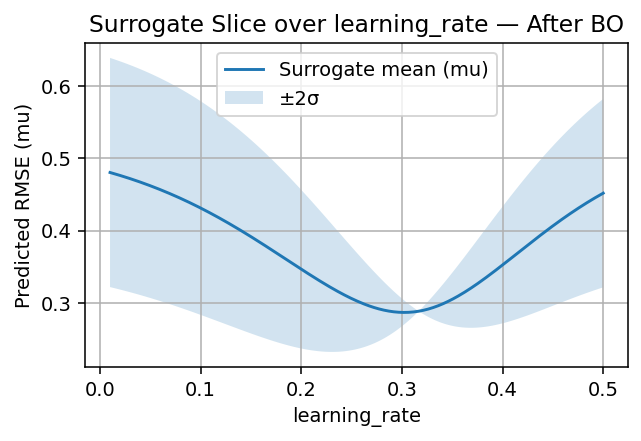

--- After BO over learning_rate ---
Range of lower 2-sigma bound: [0.2325, 0.3219]
Range of upper 2-sigma bound: [0.2892, 0.6381]



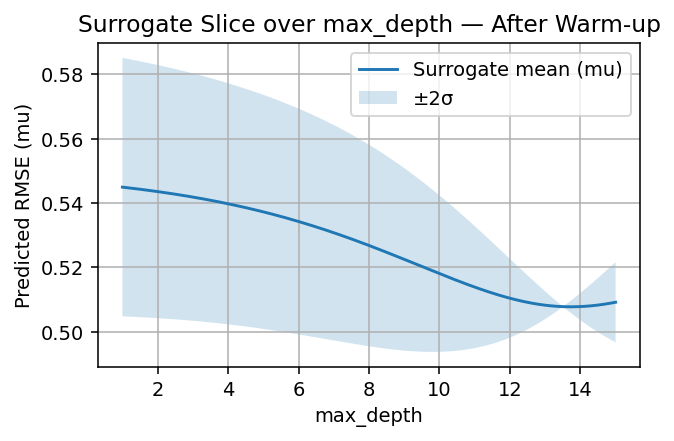

--- After Warm-up over max_depth ---
Range of lower 2-sigma bound: [0.4938, 0.5077]
Range of upper 2-sigma bound: [0.5080, 0.5851]



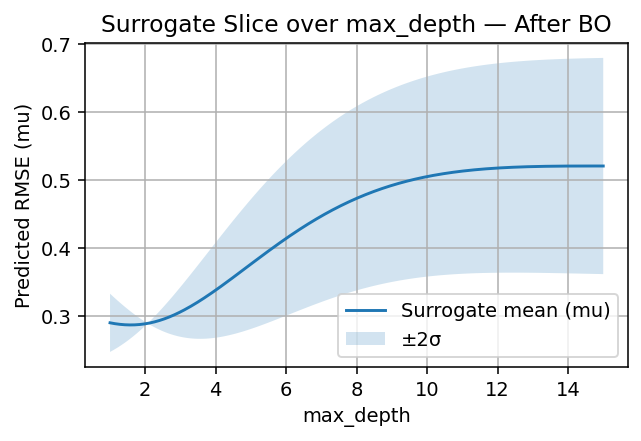

--- After BO over max_depth ---
Range of lower 2-sigma bound: [0.2467, 0.3632]
Range of upper 2-sigma bound: [0.2894, 0.6790]



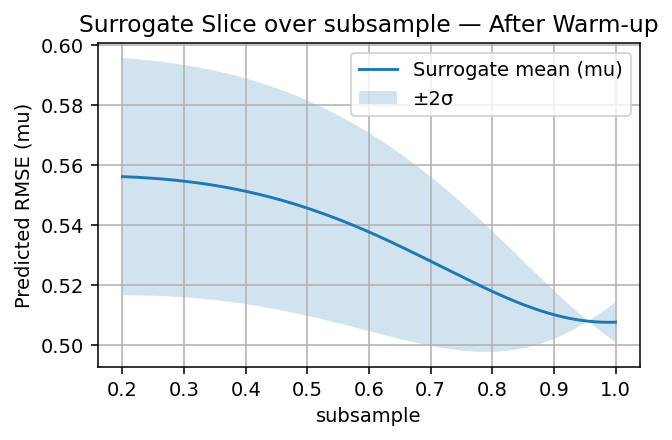

--- After Warm-up over subsample ---
Range of lower 2-sigma bound: [0.4976, 0.5164]
Range of upper 2-sigma bound: [0.5081, 0.5956]



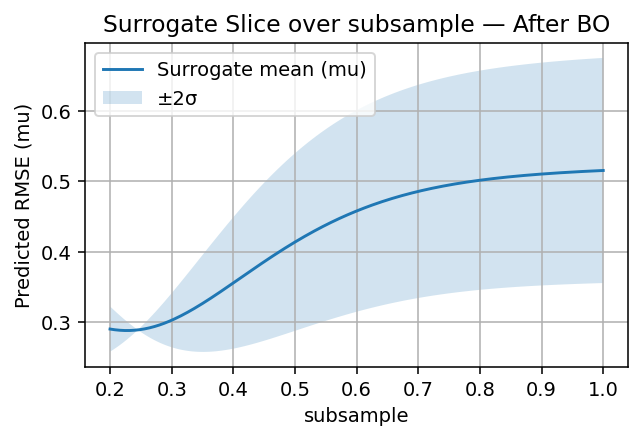

--- After BO over subsample ---
Range of lower 2-sigma bound: [0.2573, 0.3553]
Range of upper 2-sigma bound: [0.2894, 0.6757]



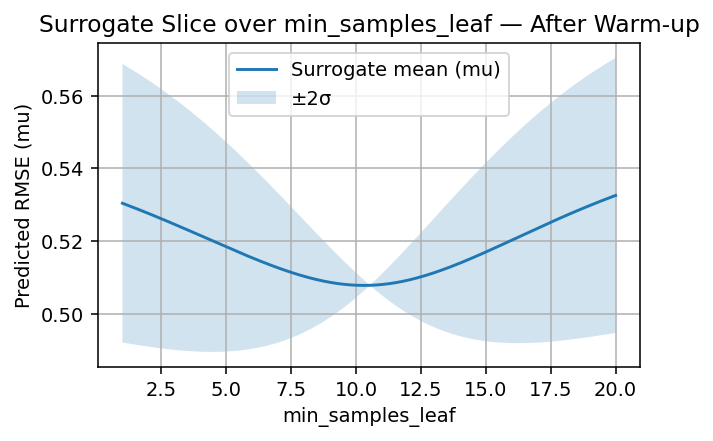

--- After Warm-up over min_samples_leaf ---
Range of lower 2-sigma bound: [0.4895, 0.5077]
Range of upper 2-sigma bound: [0.5080, 0.5704]



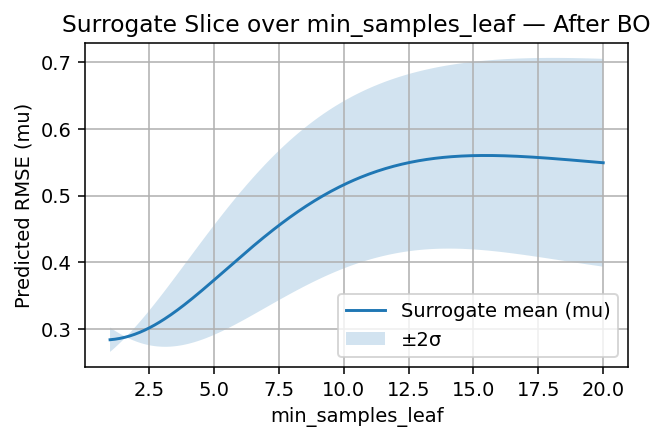

--- After BO over min_samples_leaf ---
Range of lower 2-sigma bound: [0.2664, 0.4207]
Range of upper 2-sigma bound: [0.2896, 0.7056]



In [17]:
def surrogate_slice_plot(X_used, y_used, title_suffix, hp_name_to_plot):
    gp = GaussianProcessRegressor(kernel=C(1.0)*Matern(nu=2.5)+WhiteKernel(1e-6), normalize_y=True, random_state=0)
    gp.fit(X_used, y_used)

    # Best trial so far
    best_idx = np.argmin(y_used); anchor = X_used[best_idx].copy()
    j = list(space.keys()).index(hp_name_to_plot)
    xs = np.linspace(0,1,300); grid = np.tile(anchor, (len(xs),1)); grid[:, j] = xs
    mu, std = gp.predict(grid, return_std=True)
    lo, hi = space[hp_name_to_plot]; hp_vals = lo + xs*(hi-lo)

    plt.figure()
    plt.plot(hp_vals, mu, label="Surrogate mean (mu)")
    plt.fill_between(hp_vals, mu-2*std, mu+2*std, alpha=0.2, label="±2σ")
    plt.xlabel(hp_name_to_plot); plt.ylabel("Predicted RMSE (mu)")
    plt.title(f"Surrogate Slice over {hp_name_to_plot} — {title_suffix}")
    plt.legend(); plt.show()

    # Calculate and print the ranges of the 2 sigmas
    lower_bound = mu - 2 * std
    upper_bound = mu + 2 * std
    print(f"--- {title_suffix} over {hp_name_to_plot} ---")
    print(f"Range of lower 2-sigma bound: [{np.min(lower_bound):.4f}, {np.max(lower_bound):.4f}]")
    print(f"Range of upper 2-sigma bound: [{np.min(upper_bound):.4f}, {np.max(upper_bound):.4f}]\n")

X_warm = np.array([r for r in globals()['X_trials'][:N_INIT]])
y_warm = np.array([objective(to_params(x)) for x in X_warm])

for hp_name in hp:
    surrogate_slice_plot(X_warm, y_warm, "After Warm-up", hp_name)
    surrogate_slice_plot(globals()['X_trials'], globals()['y_trials'], "After BO", hp_name)

In [18]:
print(f"Baseline RMSE: {baseline_rmse:.4f}")
print(f"Best RMSE found: {log_df['best_rmse_so_far'].min():.4f}")

Baseline RMSE: 0.4130
Best RMSE found: 0.2886


**Weekly Strategy**

1. Week 4 using a KAPPA of 100.0, the next candidate offered was [0.274425, 0.507814, 0.462264, 0.576454, 0.998962].
2. Week 5, using a KAPPA of 200.0, the next candidate offered is [0.70498344, 0.14034362, 0.25659438, 0.0237756 , 0.27067946]
3. Week 6, using a KAPPA of 500.0, the next candidate offered is [0.09232741, 0.76354081, 0.60834217, 0.09350507, 0.45938181] to explore further
4. Week 7, using a KAPPA of 10.0, the next candidate offered is [0.56090774, 0.98046274, 0.55092096, 0.99646958, 0.94461569] to exploit
5. Week 8 using a KAPPA of 1000.0 for exploration, the next candidate offered is [0.74912411, 0.62743859, 0.18613609, 0.28973666, 0.9854482] - hyperparameters changed
6. Week 9 using a KAPPA of 5.0,from BO
 - suggested next X data point (5D coordinates): [0.0383306  0.02895442 0.81532219 0.95761858 0.02705474]
 - Predicted Y at this point (mean): -9.72322e-01
 - Predicted uncertainty (std) at this point: 4.39487e-01
 - UCB value at this point: 1.22511e+00
7. Week 10 using a KAPPA of 1.0, from BO and reverting back to N_INT and N_ITER of 8.0 for a simpler parameterised BO GP model

 - Suggested next X data point (5D coordinates): [0.44992813 0.2947759  0.71454439 0.99548744 0.04675266]
 - Predicted Y at this point (mean): -4.82028e-01
 - Predicted uncertainty (std) at this point: 2.05700e-01
 - UCB value at this point: -2.76329e-01

8. Week 11 using a KAPPA of 0.5, from BO, changing hyperparamters search space for max_depth changed to 15 from 10, reduced subsample to 0.2
- Suggested next X data point (5D coordinates): [0.48969935 0.26853042 0.63174599 0.93478947 0.14613109]
 - Predicted Y at this point (mean): -4.05086e-01
 - Predicted uncertainty (std) at this point: 5.81856e-02
 - UCB value at this point: -3.75993e-01

9. Week 12 using a KAPPA of 0.5 from BO

 - Suggested next X data point (5D coordinates): [0.41244921 0.36017705 0.44729936 0.86156691 0.04119612]
 - Predicted Y at this point (mean): -3.88511e-01
 - Predicted uncertainty (std) at this point: 1.11819e-01
 - UCB value at this point: -3.32602e-01

 10. Week 13 using a KAPPA of 0.25 from BO

 - Suggested next X data point (5D coordinates): [0.48714798 0.26195869 0.46892187 0.86463964 0.01366398]
 - Predicted Y at this point (mean): -3.69068e-01
 - Predicted uncertainty (std) at this point: 4.62470e-02
 - UCB value at this point: -3.57507e-01

### Final Model (on best parameters)

Optimized hyperparameters (from BO): {'n_estimators': 112, 'learning_rate': 0.31667633278836543, 'max_depth': 2, 'subsample': 0.24507092404426276, 'min_samples_leaf': 2}
Final (BO) 5-fold RMSE: 0.289


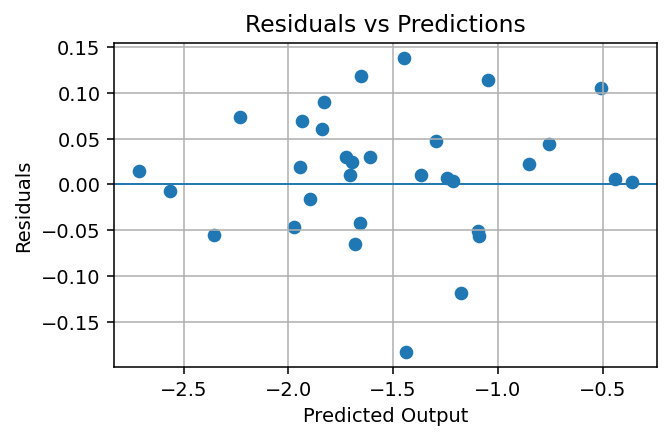

In [19]:
# The original values for max_depth and subsample were fixed within the objective function.
# We need to use those same fixed values here to initialize the final model.
# However, with the 5D optimization, max_depth and subsample are now optimized by BO.
# We should use the optimized values from best_params for the final model.

best_row = log_df.iloc[log_df["best_rmse_so_far"].idxmin()]
best_params = {k: float(best_row[k]) for k in space.keys()}

# Ensure integer hyperparameters are correctly cast
best_params["n_estimators"] = int(best_params["n_estimators"])
best_params["max_depth"] = int(best_params["max_depth"])
best_params["min_samples_leaf"] = int(best_params["min_samples_leaf"])

print("Optimized hyperparameters (from BO):", best_params)

final = GradientBoostingRegressor(
    n_estimators=best_params["n_estimators"],
    learning_rate=best_params["learning_rate"],
    max_depth=best_params["max_depth"], # Use the BO-optimized value
    subsample=best_params["subsample"], # Use the BO-optimized value
    min_samples_leaf=best_params["min_samples_leaf"],
    random_state=42
)
final_rmse = rmse_cv(final)
print("Final (BO) 5-fold RMSE:", round(final_rmse, 3))

final.fit(X, y)
pred = final.predict(X)
resid = y - pred # Corrected: subtract predictions from actual target values (y)

plt.figure()
plt.scatter(pred, resid)
plt.axhline(0, linewidth=1)
plt.xlabel("Predicted Output"); plt.ylabel("Residuals") # Changed label for generality
plt.title("Residuals vs Predictions")
plt.show()

### Log review (each step)

In [20]:
try:
    import caas_jupyter_tools as cj
    subset_cols = ["iter","tag","rmse","best_rmse_so_far","mu","sigma","ei","exploit_contrib","explore_contrib"] + list(space.keys())
    log_view = log_df[subset_cols].round(4)
    cj.display_dataframe_to_user("BayesOpt_Step_Log", log_view)
except Exception:
    pass

log_df.head(20)

,iter,tag,rmse,best_rmse_so_far,mu,sigma,ei,exploit_contrib,explore_contrib,n_estimators,learning_rate,max_depth,subsample,min_samples_leaf
0,-7,Warm-up,0.533814,0.533814,NaN,NaN,NaN,NaN,NaN,294.0,0.150208,4.0,0.641052,15.0
1,-6,Warm-up,0.560639,0.533814,NaN,NaN,NaN,NaN,NaN,198.0,0.490574,11.0,0.584746,8.0
2,-5,Warm-up,0.568608,0.533814,NaN,NaN,NaN,NaN,NaN,170.0,0.367234,7.0,0.247742,9.0
3,-4,Warm-up,0.540122,0.533814,NaN,NaN,NaN,NaN,NaN,308.0,0.099421,3.0,0.625241,11.0
4,-3,Warm-up,0.565268,0.533814,NaN,NaN,NaN,NaN,NaN,272.0,0.426222,11.0,0.688819,15.0
5,-2,Warm-up,0.566544,0.533814,NaN,NaN,NaN,NaN,NaN,163.0,0.187276,4.0,0.434971,13.0
6,-1,Warm-up,0.554918,0.533814,NaN,NaN,NaN,NaN,NaN,82.0,0.222514,7.0,0.594948,9.0
7,0,Warm-up,0.507846,0.507846,NaN,NaN,NaN,NaN,NaN,159.0,0.218912,14.0,0.955328,11.0
8,1,UCB (Exploitation),0.449113,0.449113,0.569623,0.012801,NaN,0.569623,0.003200,64.0,0.173049,14.0,0.694128,8.0
9,2,UCB (Exploitation),0.288636,0.288636,0.576236,0.026623,NaN,0.576236,0.006656,112.0,0.316676,2.0,0.245071,2.0


# **Suggesting the Next X Data Point using Bayesian Optimization**

To find the next best x (5D coordinates) to sample the mix of the 5 cake ingredients to score as close to zero as possible.

We will set up a separate Bayesian Optimization process. This process will:

Fit a Gaussian Process Regressor on the existing X (5D coordinates) and y (score). Generate a grid of candidate points across the 5D input space. Evaluate an Acquisition Function (like Upper Confidence Bound - UCB) for each candidate point. Identify the candidate point with the highest acquisition function value as the next suggested x for sampling.


# Explain the purpose of the 5D candidate search in the below cell
# The purpose of the 5D candidate search is distinct from the Bayesian Optimization process that optimized the hyperparameters of the GradientBoostingRegressor.

Here's the breakdown:

# **Earlier Bayesian Optimization (optimizing hyperparameters):**

**Goal:** To find the best GradientBoostingRegressor settings (n_estimators, learning_rate, max_depth, subsample, min_samples_leaf).

**Input (X for that BO):** The 5 hyperparameters themselves.

**Output (y for that BO):** The RMSE of the Gradient Boosting Regressor trained with those hyperparameters.

**Result:** The best_params for the GradientBoostingRegressor model.


# **5D Candidate Search in the below cell (optimizing cake ingredients):**

**Goal:** To find the best combination of the 5 cake ingredients (X from the initial dataset) to maximize the cake's score (y from the initial dataset).

**Input (X for this BO):** The actual ingredient proportions (the X array you loaded at the beginning).

**Output (y for this BO):** The scores associated with those ingredient combinations (the y array you loaded at the beginning).

**Result:** next_x_data_point, which is a suggested new 5D combination of ingredients (e.g., flour, sugar, eggs, butter, milk) that the Bayesian Optimization predicts will yield a high cake score (close to zero, as it's a maximization problem). This is a recommendation for your next experiment in the physical world (or simulated environment) to get a better-tasting cake.

In essence, the first BO helps us build a better predictive model, and the second BO in the above cell uses a similar technique but is applied to the original problem data to directly suggest better inputs for that original problem (the cake recipe)

In [21]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel as C
import numpy as np
import matplotlib.pyplot as plt

# The search space for the 5D input features for cake ingredients
# X values represent amounts of five ingredients, typically normalized between [0, 1]

d_x = X.shape[1] # Dimension of the X input space (should be 5 for the cake ingredients)

# 2. Initialize and fit a Gaussian Process Regressor on the existing ingredient data
# We'll use the same kernel structure as for hyperparameter optimization, but applied to the X, y data
# Note: Normalizing y is crucial for GP performance
kernel_3d = C(1.0, (1e-3, 1e3)) * Matern(length_scale=np.ones(d_x), nu=2.5) + WhiteKernel(noise_level=1e-6, noise_level_bounds=(1e-9, 1e-2))
gpr_3d = GaussianProcessRegressor(kernel=kernel_3d, normalize_y=True, random_state=42, n_restarts_optimizer=3)

gpr_3d.fit(X, y)

# 3. Generate a grid of candidate points across the 5D input space
n_candidates_3d = 10000 # Number of candidate points for the 5D search space

# Create a uniform grid of candidates within the defined bounds [0,1] for all five features
candidates_3d = np.random.rand(n_candidates_3d, d_x)

# 4. Predict mean and standard deviation for these candidates
mu_3d, std_3d = gpr_3d.predict(candidates_3d, return_std=True)

# 5. Compute the Upper Confidence Bound (UCB) acquisition function
# We need to decide on a KAPPA for this 5D search. A higher KAPPA means more exploration.
KAPPA_3D = KAPPA # You can adjust this value to control exploration vs. exploitation for the 5D space

# Since we are trying to MAXIMIZE the (transformed) output (minimizing side effects), (maximizing score close to zero)
# UCB is calculated as mu + KAPPA * std
ucb_acquisition = mu_3d + KAPPA_3D * std_3d

# 6. Identify the candidate point with the maximum UCB
best_ucb_idx = np.argmax(ucb_acquisition)
next_x_data_point = candidates_3d[best_ucb_idx]
predicted_y_at_next_x = mu_3d[best_ucb_idx]
predicted_std_at_next_x = std_3d[best_ucb_idx]

print(f"Suggested next X data point (5D coordinates): {next_x_data_point}")
print(f"Predicted Y at this point (mean): {predicted_y_at_next_x:.5e}")
print(f"Predicted uncertainty (std) at this point: {predicted_std_at_next_x:.5e}")
print(f"UCB value at this point: {ucb_acquisition[best_ucb_idx]:.5e}")

# For 5D data, direct 2D visualization is not appropriate for all features simultaneously.
# Instead of a scatter plot, we'll rely on the printed 5D coordinates.

Suggested next X data point (5D coordinates): [0.48714798 0.26195869 0.46892187 0.86463964 0.01366398]
Predicted Y at this point (mean): -3.69068e-01
Predicted uncertainty (std) at this point: 4.62470e-02
UCB value at this point: -3.57507e-01


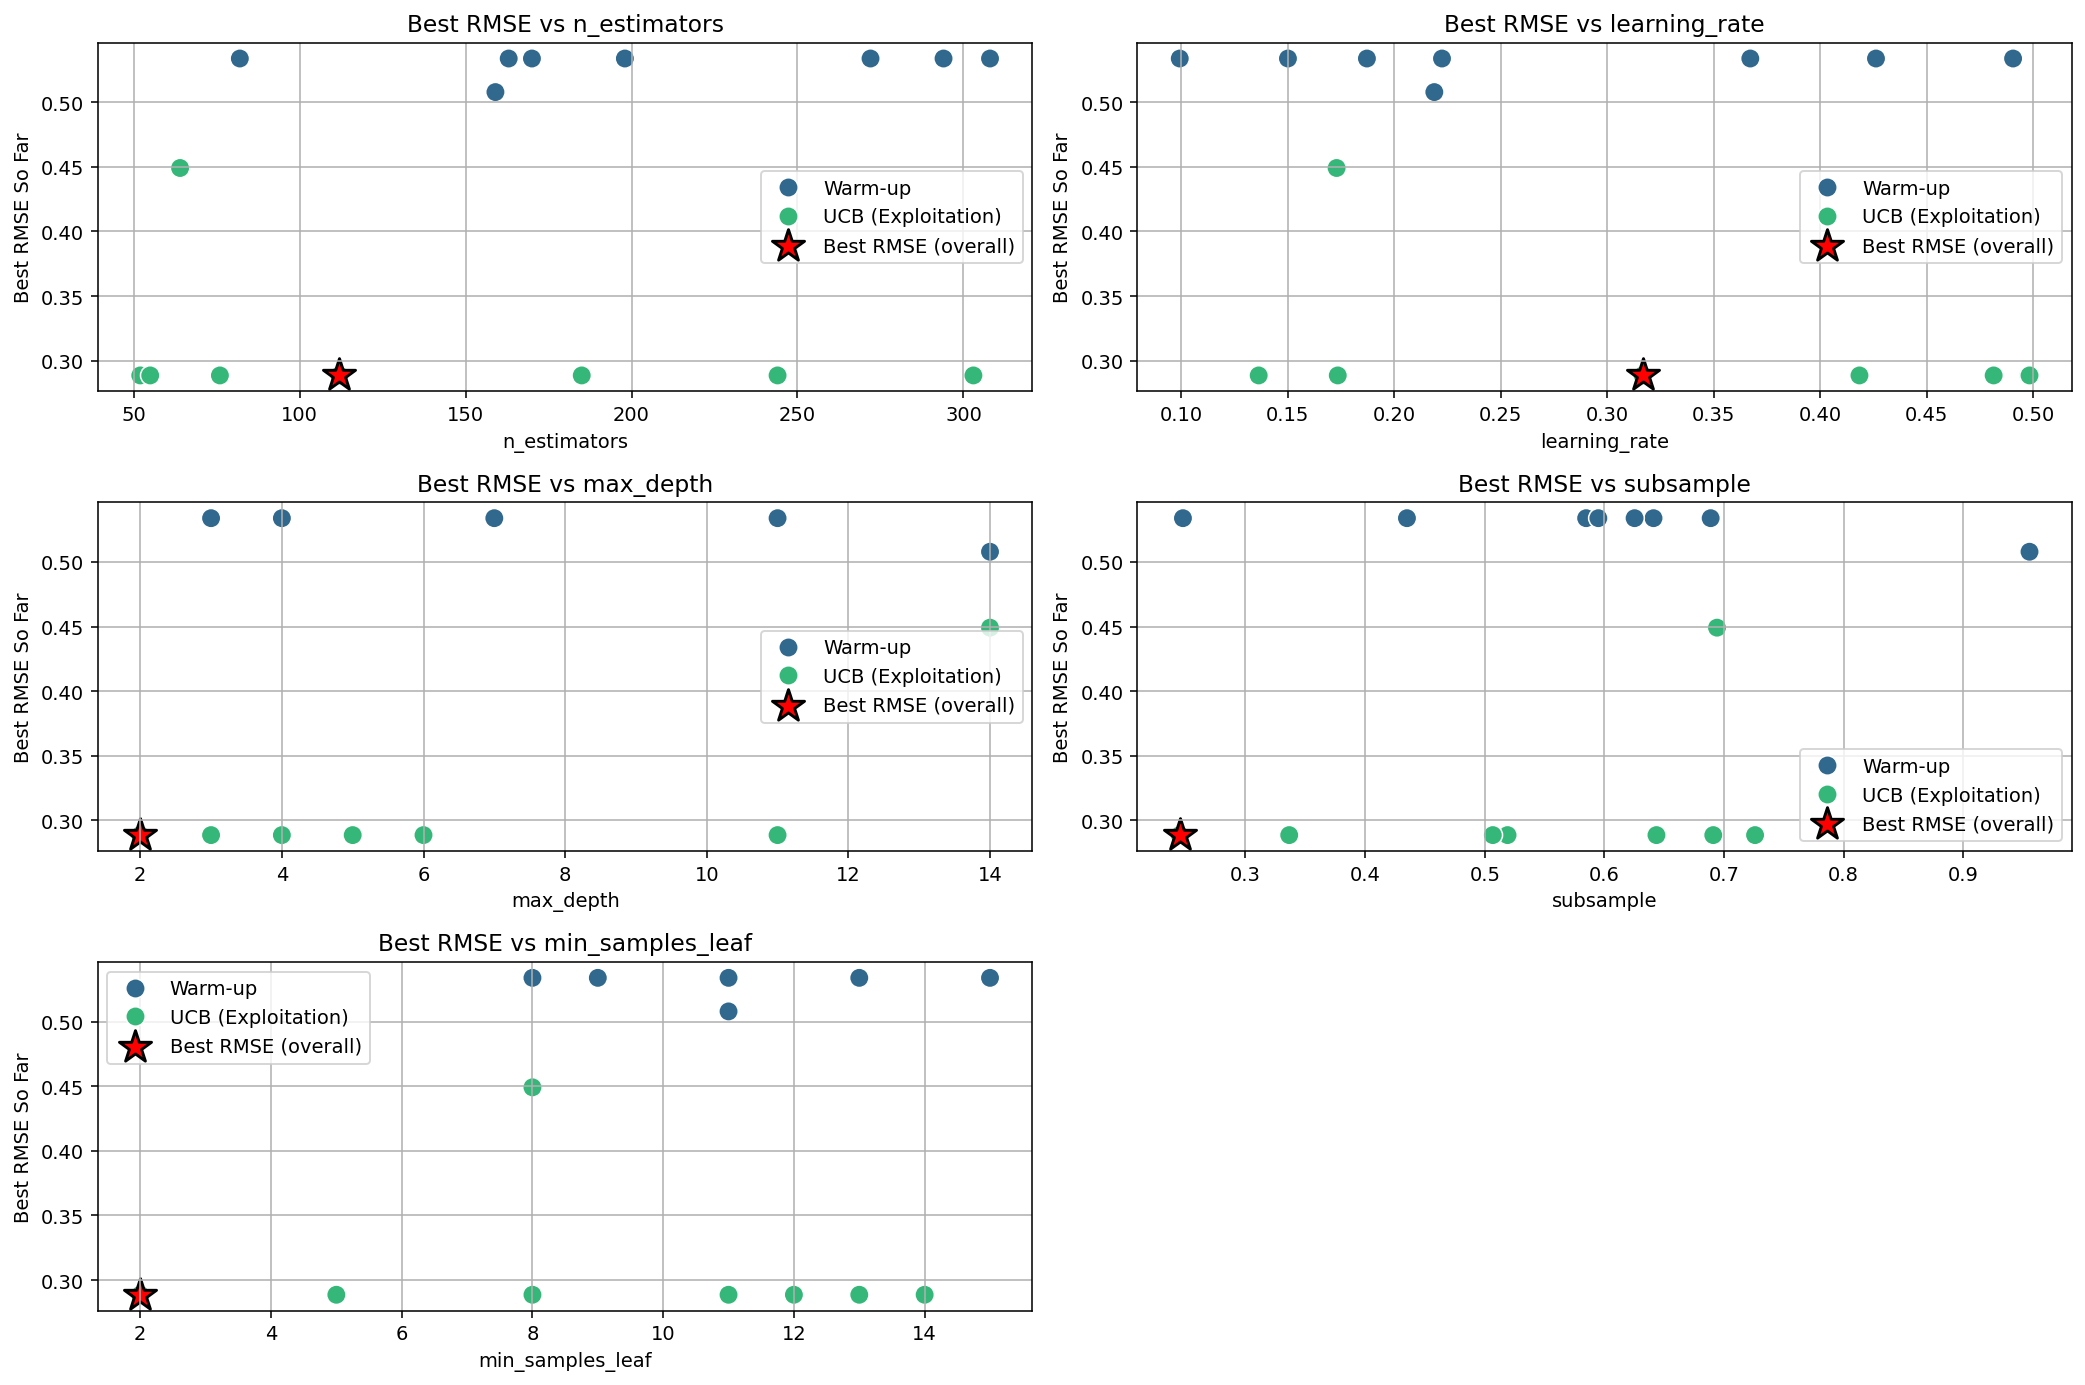

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

hyperparameters = list(space.keys())

plt.figure(figsize=(15, 10))
for i, hp_name in enumerate(hyperparameters):
    plt.subplot(3, 2, i + 1) # Changed to 3x2 grid to accommodate 5 plots
    sns.scatterplot(data=log_df, x=hp_name, y='best_rmse_so_far', hue='tag', palette='viridis', s=100)

    # Get the best RMSE and its corresponding row across all hyperparameters
    best_rmse_val_overall = log_df['best_rmse_so_far'].min()
    best_row = log_df[log_df['best_rmse_so_far'] == best_rmse_val_overall].iloc[0]

    # Highlight the best overall RMSE point for the current hyperparameter
    best_hp_value = best_row[hp_name]
    best_rmse_value = best_row['best_rmse_so_far']
    plt.scatter(best_hp_value, best_rmse_value, color='red', marker='*', s=300, edgecolor='black', linewidth=1.5, label='Best RMSE (overall)')

    plt.title(f'Best RMSE vs {hp_name}')
    plt.xlabel(hp_name)
    plt.ylabel('Best RMSE So Far')
    plt.grid(True)
    if hp_name in ['n_estimators', 'max_depth']:
        plt.ticklabel_format(useOffset=False, style='plain', axis='x') # Prevent scientific notation for integer axes
    plt.legend()

plt.tight_layout()
plt.show()

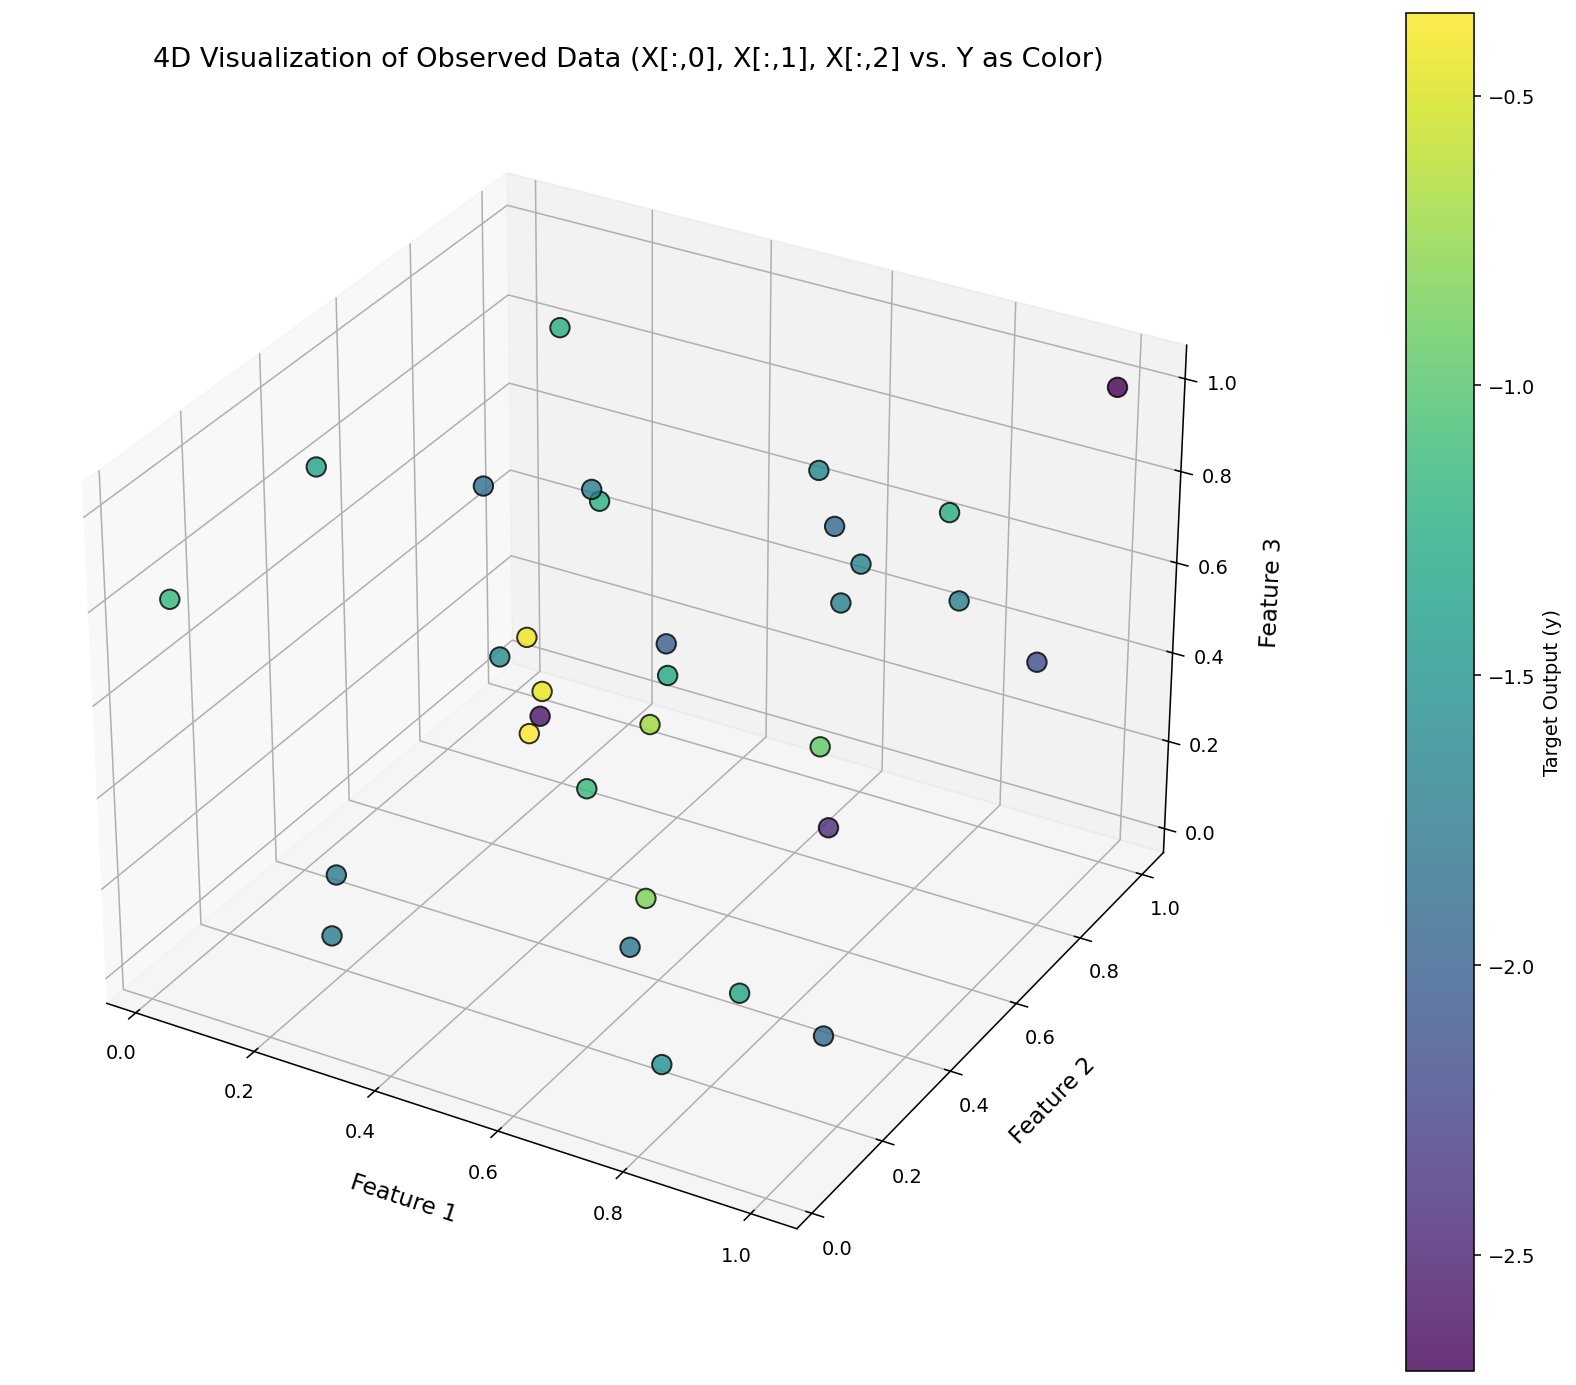

Displayed: 4D Scatter Plot of Observed Data (first 3 features)


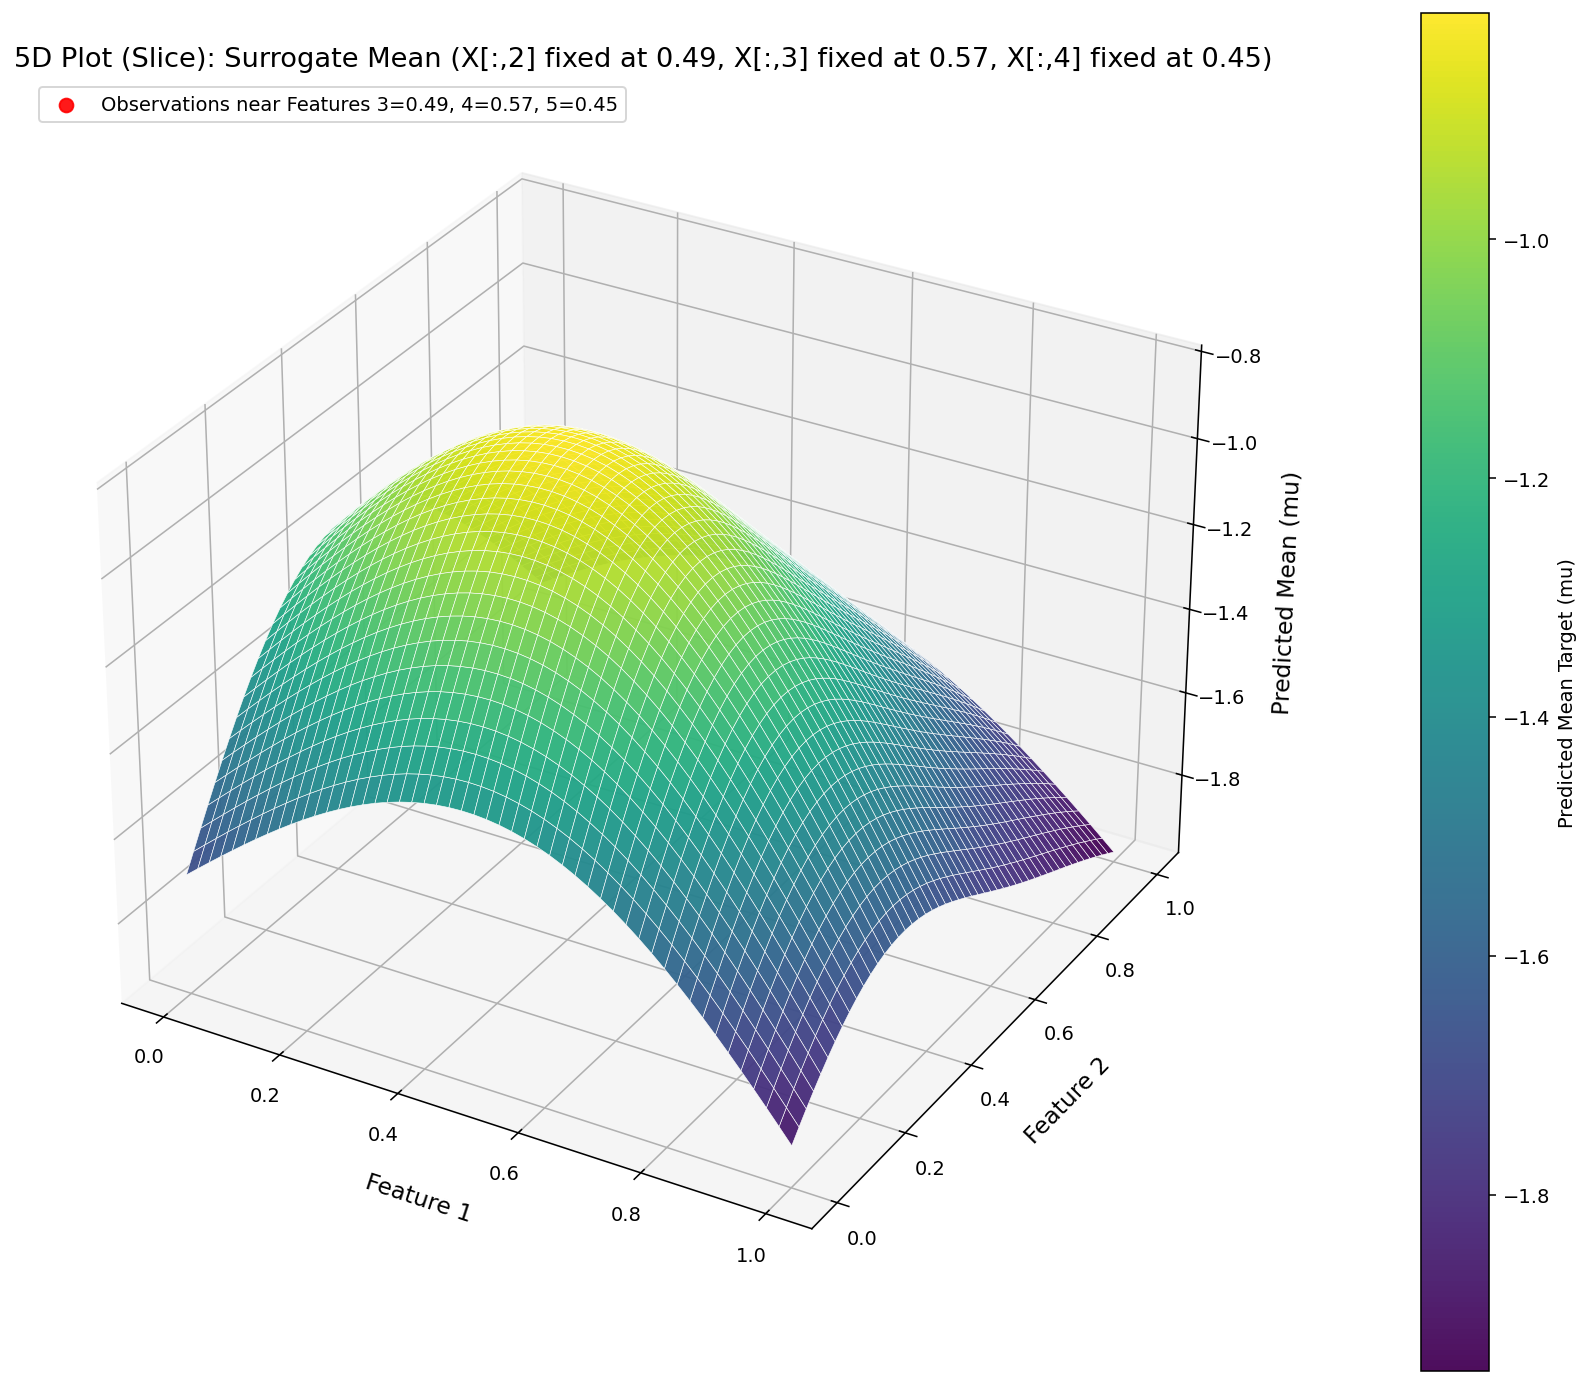

Displayed: 5D Slice Plot for Surrogate Mean (Features 3 fixed at 0.49, 4 fixed at 0.57, 5 fixed at 0.45)


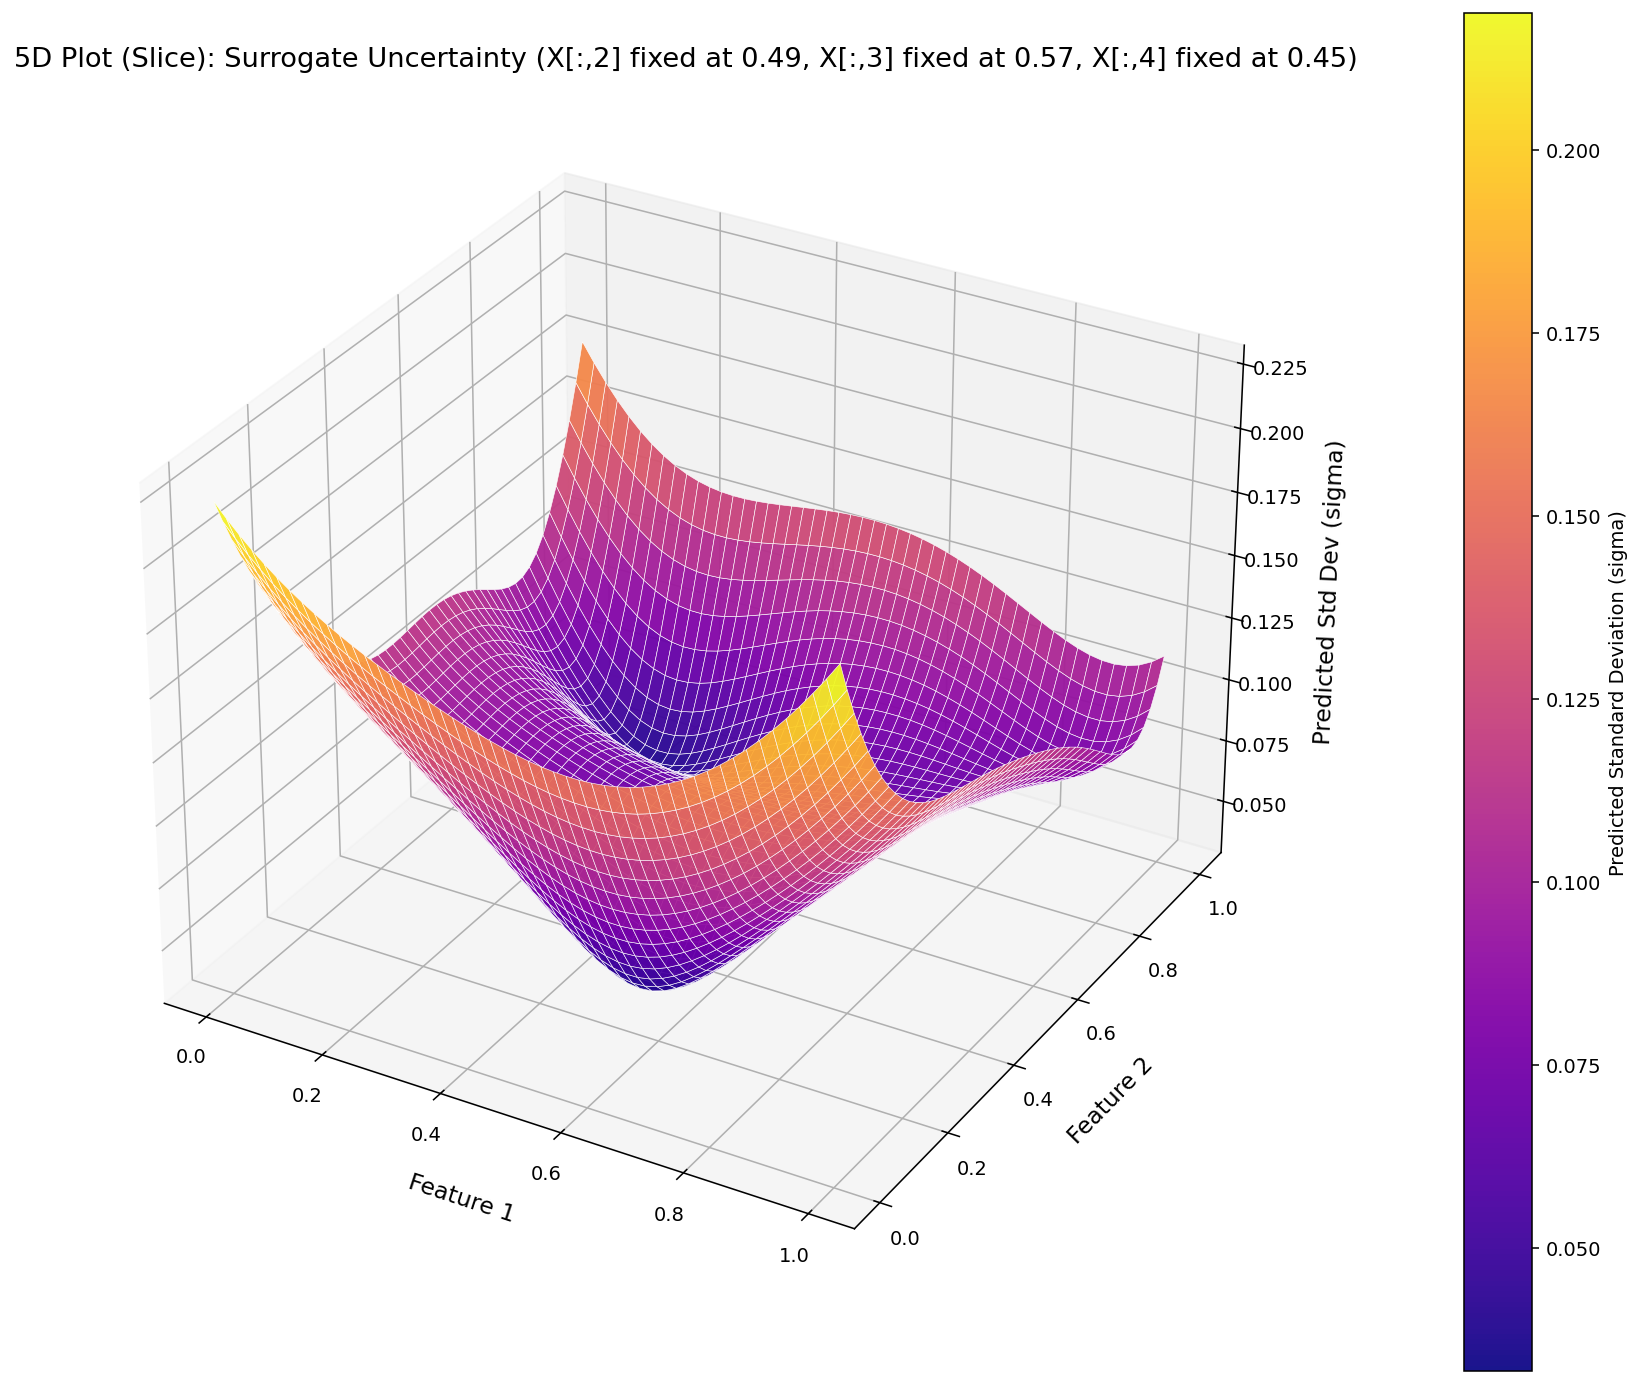

Displayed: 5D Slice Plot for Surrogate Uncertainty (Features 3 fixed at 0.49, 4 fixed at 0.57, 5 fixed at 0.45)


In [23]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel as C
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.cm as cm

resolution = 50 # Reduced resolution for faster plotting of slices

# The gpr_3d model was defined and fitted in cell 'qd_rPFSHpykn'
gp = gpr_3d

# Observed data
X_obs = X # Global variable X from the notebook state (5D input)
y_obs = y # Global variable y from the notebook state (1D output)

# ───────────────────────────────
# 1. 4D Plot: 3D Scatter Plot of Observations with Color representing Y
#    (Visualizing the first 3 features and the target Y)
# ───────────────────────────────
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# Create a colormap based on the range of y_obs values
scatter = ax.scatter(
    X_obs[:, 0], X_obs[:, 1], X_obs[:, 2],
    c=y_obs, # Color represents the 4th dimension (y_obs)
    cmap='viridis', # Choose a colormap
    s=100, # Marker size
    edgecolor='k', # Black edge for markers
    alpha=0.8
)

# Add a color bar
cbar = fig.colorbar(scatter, ax=ax, pad=0.1)
cbar.set_label('Target Output (y)')

ax.set_title('4D Visualization of Observed Data (X[:,0], X[:,1], X[:,2] vs. Y as Color)', fontsize=14)
ax.set_xlabel('Feature 1', fontsize=12, labelpad=10)
ax.set_ylabel('Feature 2', fontsize=12, labelpad=10)
ax.set_zlabel('Feature 3', fontsize=12, labelpad=10)
ax.tick_params(axis='both', labelsize=10)
plt.tight_layout()
plt.savefig('observed_data_4d.png', dpi=300, bbox_inches='tight') # Save the plot
plt.show()
print("Displayed: 4D Scatter Plot of Observed Data (first 3 features)")

# ───────────────────────────────
# 2. 5D Plot (Slice): Surrogate Mean Surface by fixing Features 3, 4, and 5
#    This shows a 3D slice of the 5D surrogate function (2 inputs + 1 output)
# ───────────────────────────────
fig2 = plt.figure(figsize=(12, 10))
ax2 = fig2.add_subplot(111, projection='3d')

# Define ranges for the two features we will vary
x1_min, x1_max = 0, 1
x2_min, x2_max = 0, 1

# Create a grid for X[:,0] and X[:,1]
x1_grid = np.linspace(x1_min, x1_max, resolution)
x2_grid = np.linspace(x2_min, x2_max, resolution)
X1, X2 = np.meshgrid(x1_grid, x2_grid)

# Fix Feature 3 (X[:,2]), Feature 4 (X[:,3]), and Feature 5 (X[:,4]) at their mean values
fixed_x3_value = np.mean(X_obs[:, 2])
fixed_x4_value = np.mean(X_obs[:, 3])
fixed_x5_value = np.mean(X_obs[:, 4])

# Create the 5D input grid for prediction for this slice
# Each point will be [X1_val, X2_val, fixed_x3_value, fixed_x4_value, fixed_x5_value]
X_slice_grid = np.column_stack([X1.ravel(), X2.ravel(),
                                np.full(X1.size, fixed_x3_value),
                                np.full(X1.size, fixed_x4_value),
                                np.full(X1.size, fixed_x5_value)])

# Predict mean and std for this slice from the GPR
mu_slice, std_slice = gp.predict(X_slice_grid, return_std=True)
Mu_slice_surface = mu_slice.reshape(resolution, resolution)
Std_slice_surface = std_slice.reshape(resolution, resolution)

# Plot the surrogate mean surface
surf_mean = ax2.plot_surface(
    X1, X2, Mu_slice_surface,
    cmap='viridis',
    edgecolor='white',
    linewidth=0.3,
    alpha=0.95
)

# Scatter the observed points that are close to the fixed feature values
tolerance = 0.1 # Define a tolerance for "close"
close_points_mask = ((X_obs[:, 2] >= fixed_x3_value - tolerance) & (X_obs[:, 2] <= fixed_x3_value + tolerance)) & \
                    ((X_obs[:, 3] >= fixed_x4_value - tolerance) & (X_obs[:, 3] <= fixed_x4_value + tolerance)) & \
                    ((X_obs[:, 4] >= fixed_x5_value - tolerance) & (X_obs[:, 4] <= fixed_x5_value + tolerance))
ax2.scatter(
    X_obs[close_points_mask, 0], X_obs[close_points_mask, 1], y_obs[close_points_mask],
    color='red', s=50, zorder=5, label=f'Observations near Features 3={fixed_x3_value:.2f}, 4={fixed_x4_value:.2f}, 5={fixed_x5_value:.2f}', alpha=0.9
)


# Add a color bar for the surface
cbar_mean = fig2.colorbar(surf_mean, ax=ax2, pad=0.1)
cbar_mean.set_label('Predicted Mean Target (mu)')

ax2.set_title(f'5D Plot (Slice): Surrogate Mean (X[:,2] fixed at {fixed_x3_value:.2f}, X[:,3] fixed at {fixed_x4_value:.2f}, X[:,4] fixed at {fixed_x5_value:.2f})', fontsize=14)
ax2.set_xlabel('Feature 1', fontsize=12, labelpad=10)
ax2.set_ylabel('Feature 2', fontsize=12, labelpad=10)
ax2.set_zlabel('Predicted Mean (mu)', fontsize=12, labelpad=10)
ax2.tick_params(axis='both', labelsize=10)
ax2.legend(loc='upper left', fontsize=10)
plt.tight_layout()
plt.savefig('surrogate_mean_slice_5d.png', dpi=300, bbox_inches='tight') # Save the plot
plt.show()
print(f"Displayed: 5D Slice Plot for Surrogate Mean (Features 3 fixed at {fixed_x3_value:.2f}, 4 fixed at {fixed_x4_value:.2f}, 5 fixed at {fixed_x5_value:.2f})")

# ───────────────────────────────
# 3. 5D Plot (Slice): Surrogate Uncertainty Surface by fixing Features 3, 4, and 5
# ───────────────────────────────
fig3 = plt.figure(figsize=(12, 10))
ax3 = fig3.add_subplot(111, projection='3d')

# Plot the surrogate uncertainty surface
surf_std = ax3.plot_surface(
    X1, X2, Std_slice_surface,
    cmap='plasma', # Good for uncertainty
    edgecolor='white',
    linewidth=0.3,
    alpha=0.95
)

# Scatter the observed points that are close to the fixed_x3_value and fixed_x4_value (optional)
ax3.scatter(
    X_obs[close_points_mask, 0], X_obs[close_points_mask, 1], np.zeros_like(y_obs[close_points_mask]), # Project to Z=0 for context
    color='red', s=50, zorder=5, label=f'Observations near Features 3={fixed_x3_value:.2f}, 4={fixed_x4_value:.2f}, 5={fixed_x5_value:.2f}', alpha=0.9
)

# Add a color bar for the uncertainty surface
cbar_std = fig3.colorbar(surf_std, ax=ax3, pad=0.1)
cbar_std.set_label('Predicted Standard Deviation (sigma)')

ax3.set_title(f'5D Plot (Slice): Surrogate Uncertainty (X[:,2] fixed at {fixed_x3_value:.2f}, X[:,3] fixed at {fixed_x4_value:.2f}, X[:,4] fixed at {fixed_x5_value:.2f})', fontsize=14)
ax3.set_xlabel('Feature 1', fontsize=12, labelpad=10)
ax3.set_ylabel('Feature 2', fontsize=12, labelpad=10)
ax3.set_zlabel('Predicted Std Dev (sigma)', fontsize=12, labelpad=10)
ax3.tick_params(axis='both', labelsize=10)
plt.tight_layout()
plt.savefig('surrogate_uncertainty_slice_5d.png', dpi=300, bbox_inches='tight') # Save the plot
plt.show()
print(f"Displayed: 5D Slice Plot for Surrogate Uncertainty (Features 3 fixed at {fixed_x3_value:.2f}, 4 fixed at {fixed_x4_value:.2f}, 5 fixed at {fixed_x5_value:.2f})")

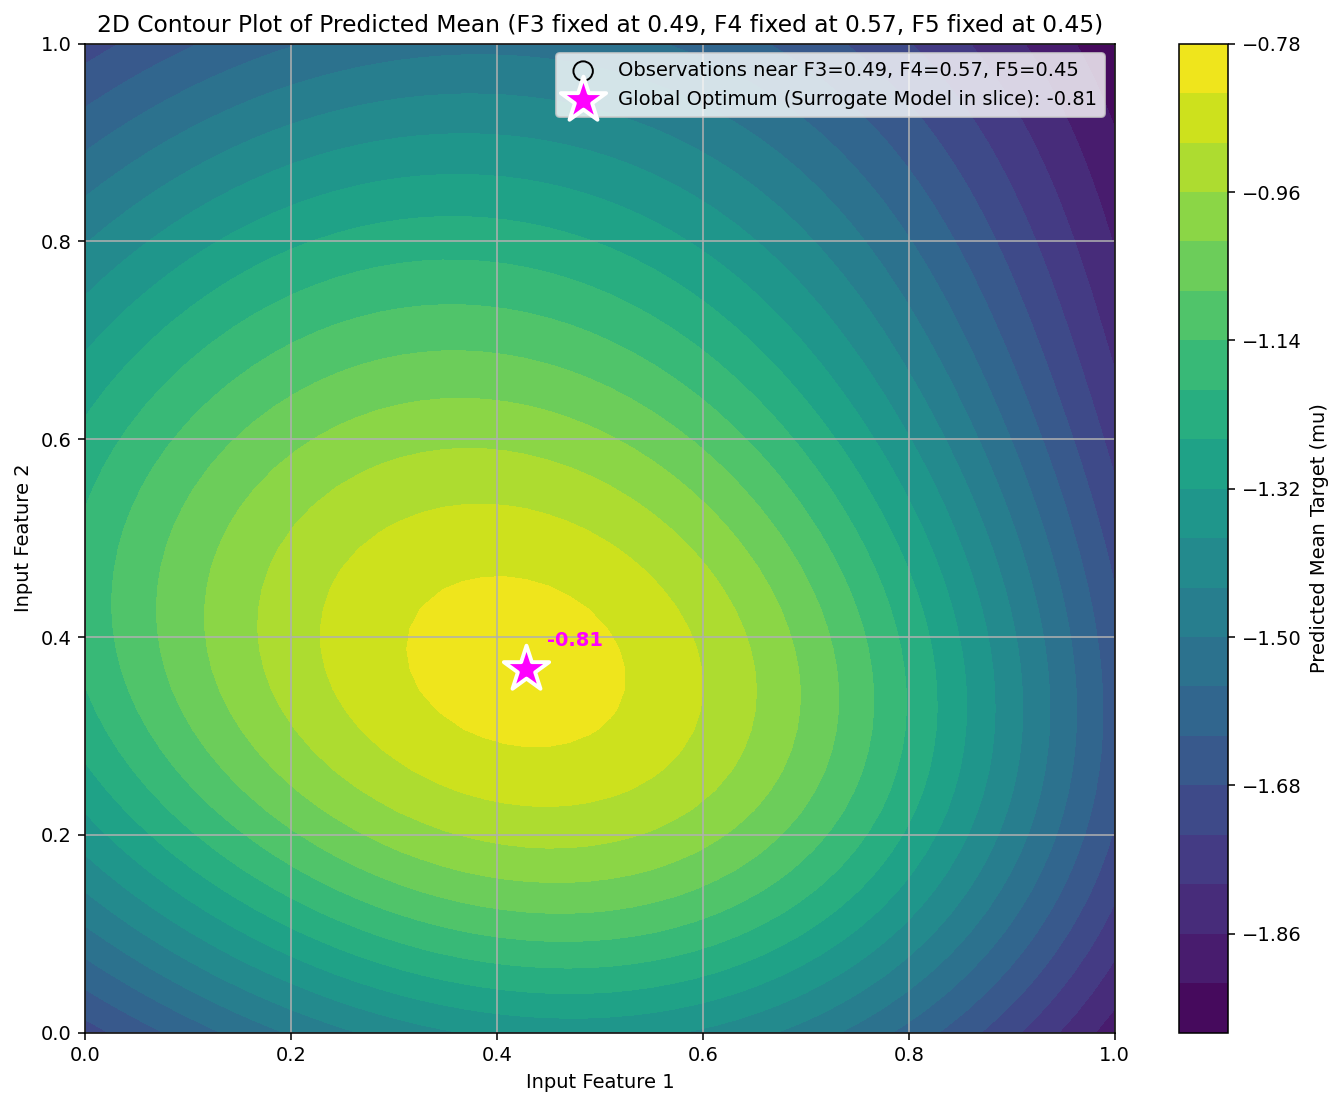

Saved: gp_surrogate_mean_contour_5d_input_slice.png

Global Optimum within slice (X1, X2, fixed X3, fixed X4, fixed X5): [0.42857143 0.36734694 0.4916241  0.56969109 0.44596027]
Predicted Mean Target (yield) at this point: -8.10002e-01


In [24]:
import numpy as np
import matplotlib.pyplot as plt

# Assuming gpr_3d, X, y, next_x_data_point, predicted_y_at_next_x are available from previous cells.

# Define parameters for the 2D slice visualization (fixing Features 3, 4 and 5)
# Using mean values of observed data for fixed features, similar to the 5D slice plots in the previous cell
fixed_x3_value = np.mean(X[:, 2])
fixed_x4_value = np.mean(X[:, 3])
fixed_x5_value = np.mean(X[:, 4])
resolution = 50 # Resolution for the grid of the 2D slice

# Create a grid for X[:,0] and X[:,1]
x1_grid = np.linspace(0, 1, resolution)
x2_grid = np.linspace(0, 1, resolution)
X1, X2 = np.meshgrid(x1_grid, x2_grid)

# Create the 5D input grid for prediction for this slice
# Each point will be [X1_val, X2_val, fixed_x3_value, fixed_x4_value, fixed_x5_value]
X_slice_grid = np.column_stack([X1.ravel(), X2.ravel(),
                                np.full(X1.size, fixed_x3_value),
                                np.full(X1.size, fixed_x4_value),
                                np.full(X1.size, fixed_x5_value)])

# Predict mean from the fitted GPR (gpr_3d)
mu_slice, _ = gpr_3d.predict(X_slice_grid, return_std=True)
Mu_slice_surface = mu_slice.reshape(resolution, resolution)

fig, ax = plt.subplots(figsize=(10, 8)) # Get fig and ax objects
contour = ax.contourf(X1, X2, Mu_slice_surface, levels=20, cmap='viridis')
fig.colorbar(contour, ax=ax, label='Predicted Mean Target (mu)')

# Scatter the observed points that are close to the fixed feature values
tolerance = 0.1 # Define a tolerance for "close"
close_points_mask = ((X[:, 2] >= fixed_x3_value - tolerance) & (X[:, 2] <= fixed_x3_value + tolerance)) & \
                    ((X[:, 3] >= fixed_x4_value - tolerance) & (X[:, 3] <= fixed_x4_value + tolerance)) & \
                    ((X[:, 4] >= fixed_x5_value - tolerance) & (X[:, 4] <= fixed_x5_value + tolerance))
ax.scatter(
    X[close_points_mask, 0], X[close_points_mask, 1], c=y[close_points_mask],
    cmap='viridis', s=100, edgecolors='k', label=f'Observations near F3={fixed_x3_value:.2f}, F4={fixed_x4_value:.2f}, F5={fixed_x5_value:.2f}'
)

# Mark the suggested next sample point (if it falls within this slice)
# Check all fixed features for proximity
if np.isclose(next_x_data_point[2], fixed_x3_value, atol=tolerance) and \
   np.isclose(next_x_data_point[3], fixed_x4_value, atol=tolerance) and \
   np.isclose(next_x_data_point[4], fixed_x5_value, atol=tolerance):
    ax.scatter(next_x_data_point[0], next_x_data_point[1],
                color='red', marker='X', s=200, label='Suggested Next Sample Point', zorder=5)

# Find the global maximum of Mu_slice_surface (as we are maximizing the transformed output)
# This is the global optimum *within this specific 2D slice* (for the two varying features)
max_mu_slice_idx = np.argmax(Mu_slice_surface)
# Get the 5D coordinates of this point within the slice
max_mu_slice_coords_flattened = X_slice_grid[max_mu_slice_idx]
max_mu_value_in_slice = Mu_slice_surface.max()

ax.scatter(
    max_mu_slice_coords_flattened[0], max_mu_slice_coords_flattened[1],
    color='magenta', marker='*', s=600, zorder=10, edgecolor='white', linewidth=2,
    label=f'Global Optimum (Surrogate Model in slice): {max_mu_value_in_slice:.2f}'
)

# Add text annotation for clarity
ax.text(max_mu_slice_coords_flattened[0] + 0.02, max_mu_slice_coords_flattened[1] + 0.02,
         f'{max_mu_value_in_slice:.2f}', color='magenta', fontsize=10, ha='left', va='bottom', weight='bold')

ax.set_title(f'2D Contour Plot of Predicted Mean (F3 fixed at {fixed_x3_value:.2f}, F4 fixed at {fixed_x4_value:.2f}, F5 fixed at {fixed_x5_value:.2f})')
ax.set_xlabel('Input Feature 1')
ax.set_ylabel('Input Feature 2')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.savefig('gp_surrogate_mean_contour_5d_input_slice.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: gp_surrogate_mean_contour_5d_input_slice.png")
print(f"\nGlobal Optimum within slice (X1, X2, fixed X3, fixed X4, fixed X5): {max_mu_slice_coords_flattened}")
print(f"Predicted Mean Target (yield) at this point: {max_mu_value_in_slice:.5e}")

In [25]:
import numpy as np

# --- 1. Global Maximum identified from Observed Data (y) ---
max_y_observed = np.max(y)
max_y_observed_idx = np.argmax(y)
max_X_observed = X[max_y_observed_idx]

print(f"\nObserved Global Maximum 'y' value: {max_y_observed:.5e}")
print(f"Corresponding 'X' values (Index {max_y_observed_idx}): {max_X_observed}")

# --- 2. Predicted Global Maximum (based on Surrogate Model gpr_3d) ---
# The gpr_3d model was already fitted in cell '4HScECjpuxOK' on X and y
# We will use the 'mu_3d' array which contains the predicted mean 'y' values for 'candidates_3d'

# Find the index of the maximum predicted mean 'y' value among all candidates
predicted_global_max_idx = np.argmax(mu_3d)
predicted_global_max_y = mu_3d[predicted_global_max_idx]
predicted_global_max_X = candidates_3d[predicted_global_max_idx]

# Get the uncertainty (standard deviation) at this predicted global maximum point
predicted_global_max_std = std_3d[predicted_global_max_idx]

print(f"\nPredicted Global Maximum 'y' value (from surrogate mean): {predicted_global_max_y:.5e}")
print(f"Corresponding 'X' values: {predicted_global_max_X}")
print(f"Uncertainty (std) at this predicted point: {predicted_global_max_std:.5e}")


Observed Global Maximum 'y' value: -3.57630e-01
Corresponding 'X' values (Index 31): [0.412449 0.360177 0.447299 0.861567 0.041196]

Predicted Global Maximum 'y' value (from surrogate mean): -3.69068e-01
Corresponding 'X' values: [0.48714798 0.26195869 0.46892187 0.86463964 0.01366398]
Uncertainty (std) at this predicted point: 4.62470e-02
